# Pipeline de Poda Estruturada — MLP no CIFAR-10

**Objetivo:** Comparar **Poda Estruturada Local** vs **Poda Estruturada Global** utilizando critérios de saliência por magnitude (**Normas L1 e L2**) numa rede MLP (*Multi-Layer Perceptron*) totalmente ligada, validando o impacto e a resiliência de duas abordagens de remoção: **Poda One-Shot** e **Poda Iterativa (Progressiva)** ao longo de múltiplos níveis de esparsidade.

Este notebook implementa:

1. **Configuração e Importações** — Inicialização do ambiente, garantia de reprodutibilidade com sementes fixas e monitorização da pegada de VRAM.
2. **Estimativa de Saliência por Magnitude** — Implementação e comparação das funções de importância baseadas nas Normas L1 (Soma de Manhattan) e L2 (Magnitude Euclidiana) para os neurónios.
3. **Reconstrução Física das Camadas** — Algoritmo de manipulação in-place de tensores que reconstrói dinamicamente a arquitetura da rede, ajustando caminhos adjacentes (`Linear` e `BatchNorm1d`) sem recorrer a máscaras de zeros.
4. **Estratégias de Controlo da Poda** — Orquestração de dois fluxos experimentais:
   * **One-Shot:** Remoção integral e imediata da esparsidade alvo seguida de re-otimização.
   * **Iterativa (Progressiva):** Remoção faseada em múltiplos sub-passos com recalibração matemática do rácio relativo remanescente e aplicação de épocas adaptativas.
5. **Ajuste Fino (*Fine-Tuning*)** — Ciclos rápidos de recuperação pós-poda utilizando o otimizador SGD com Momentum e barra de progresso `tqdm` integrada por lote.
6. **Pipeline Experimental Automatizado** — Execução em bloco de todas as permutações de testes cruzando Métodos × Normas × Estratégias para rácios de 10% a 70%.
7. **Avaliação Global e Visualização** — Consolidação dos resultados num DataFrame estilizado do Pandas e geração de três gráficos comparativos integrados (Curva de Degradação de Exatidão, Redução de Latência e Eficiência de Compressão vs Speedup).

---
## 1. Setup e Importações

Carregamento de todas as dependências, importação das arquiteturas e métricas de `utils.py`, e configuração do dispositivo de computação com tracking inicial de memória VRAM.

In [94]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision.transforms import v2
import matplotlib.pyplot as plt
import numpy as np
import random
import copy
import time
from pathlib import Path
from tqdm import tqdm
from torch.utils.data import DataLoader, Subset
import os
import pickle
import pandas as pd
from IPython.display import display
import seaborn as sns
import matplotlib.pyplot as plt
import torch
import re
import pandas as pd
from pathlib import Path

# Importações do utils.py
from utils import (
    CIFAR10MLP,
    evaluate_model,
    compute_metrics,
    train_model,
    classes
)

# Reprodutibilidade
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Dispositivo (foco em CUDA)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

if device.type == "cuda":
    torch.cuda.reset_peak_memory_stats()
    vram_initial = torch.cuda.memory_allocated(device) / (1024**2)
    print(f"GPU: {torch.cuda.get_device_name(device)}")
    print(f"VRAM alocada inicialmente: {vram_initial:.2f} MB")
else:
    print("AVISO: CUDA não disponível. Os resultados de VRAM serão 0.")

Device: cuda
GPU: NVIDIA GeForce RTX 3060 Laptop GPU
VRAM alocada inicialmente: 574.54 MB


### Carregamento de Dados — Split Determinístico

Para garantir uma comparação justa entre as experiências de poda, reutilizamos o split
determinístico treino/validação gerado durante o treino do baseline.

In [95]:
# Pipeline de Transformação de Imagen
# Utilizamos a API v2 da torchvision
transform = v2.Compose([
    v2.ToImage(),  # Converte os dados brutos (PIL Image ou NumPy) para o formato de imagem interno do PyTorch.
    v2.ToDtype(torch.float32, scale=True),  # Converte para tensores de precisão simples (float32) e escala os pixéis de [0, 255] para [0.0, 1.0].
    v2.Normalize(
        mean=(0.4914, 0.4822, 0.4465),  # Média exata dos canais RGB calculada previamente para o CIFAR-10.
        std=(0.2470, 0.2435, 0.2616)    # Desvio padrão exato dos canais RGB do CIFAR-10. Ajuda a rede a treinar mais rápido e de forma estável.
    )
])

# Carregamento dos Datasets Brutos 
# Fazemos e aplicamos as transformações definidas acima.
full_trainset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=transform
)
testset = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=transform
)

# Divisão Determinística (Treino / Validação)
# Em vez de fazermos um split aleatório carregamos os índices guardados no disco.
# Isto garante reprodutibilidade: vai treinar e validar exatamente com as mesmas imagens em todas as experiências.
split = torch.load("data/cifar10_split.pt", weights_only=False)
train_indices = split["train_indices"]
val_indices = split["val_indices"]

# Aplicamos os índices para criar os subconjuntos definitivos.
trainset = Subset(full_trainset, train_indices)
valset = Subset(full_trainset, val_indices)

# Criação dos DataLoaders
batch_size = 64


trainloader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=2)

valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=2)

print(f"Train: {len(trainset):,} | Val: {len(valset):,} | Test: {len(testset):,}")

Train: 42,500 | Val: 7,500 | Test: 10,000


### Carregamento do Modelo Baseline

Carregamento do MLP pré-treinado no CIFAR-10. Este modelo serve como ponto de referência
para todas as experiências de poda subsequentes.

In [96]:
# Definição do Caminho do Modelo
models_dir = Path('model_dir')
PATH_MLP = models_dir / 'cifar_mlp.pt'


# Carregamos o modelo primeiro para o CPU (map_location='cpu'). Esta é uma boa prática 
# para evitar picos de memória na GPU ou erros caso o modelo tenha sido treinado num PC diferente.
# weights_only=False indica que estamos a carregar o objeto do modelo inteiro (arquitetura + pesos), 
# e não apenas o dicionário de pesos (state_dict).
baseline_model = torch.load(PATH_MLP, map_location=torch.device('cpu'), weights_only=False) 

# Transferimos o modelo para o dispositivo de processamento ativo (GPU se disponível, senão CPU).
baseline_model = baseline_model.to(device)

# Colocamos a rede em modo de avaliação. 
baseline_model.eval()

print(baseline_model)

print(f"\nTotal de parâmetros: {sum(p.numel() for p in baseline_model.parameters()):,}")

# Se estivermos a usar uma placa gráfica da NVIDIA (CUDA), verificamos a pegada de memória
# exata que a rede não podada ocupa. (1024**2 converte bytes para Megabytes).
if device.type == "cuda":
    vram_model = torch.cuda.memory_allocated(device) / (1024**2)
    print(f"VRAM após carregar modelo: {vram_model:.2f} MB")

CIFAR10MLP(
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3072, out_features=2048, bias=True)
    (2): BatchNorm1d(2048, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (3): ReLU()
    (4): Dropout(p=0.3, inplace=False)
    (5): Linear(in_features=2048, out_features=1024, bias=True)
    (6): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (7): ReLU()
    (8): Dropout(p=0.3, inplace=False)
    (9): Linear(in_features=1024, out_features=512, bias=True)
    (10): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
    (11): ReLU()
    (12): Dropout(p=0.2, inplace=False)
    (13): Linear(in_features=512, out_features=10, bias=True)
  )
)

Total de parâmetros: 8,928,778
VRAM após carregar modelo: 573.58 MB


---
## 2. Funções de Saliência para Estimativa de Importância dos Neurónios

A saliência de cada neurónio é calculada com base na norma dos seus pesos.
Neurónios com menor saliência são considerados menos importantes e são candidatos à remoção.

Para o neurónio $j$ na camada com pesos $W$:

**Norma L1:**  $S_j = \sum_i |w_{ij}|$

**Norma L2:**  $S_j = \sqrt{\sum_i w_{ij}^2}$

In [97]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader

# ── 1. Saliência por Magnitude (Norma L1) ──
def compute_l1_saliency(layer: nn.Linear, **kwargs) -> torch.Tensor:
    W = layer.weight.data 
    return torch.sum(torch.abs(W), dim=1) 

# ── 2. Saliência por Magnitude (Norma L2) ──
def compute_l2_saliency(layer: nn.Linear, **kwargs) -> torch.Tensor:
    W = layer.weight.data
    return torch.norm(W, p=2, dim=1)

# ── 3. Saliência por Informação de Gradiente (Expansão de Taylor de 1ª Ordem) ──
def compute_taylor_saliency(layer: nn.Module, model: nn.Module = None, calibration_loader: DataLoader = None, device: torch.device = None, **kwargs) -> torch.Tensor:
    activations = []
    gradients = []
    
    def f_hook(module, input, output): 
        activations.append(output.detach())
    def b_hook(module, grad_in, grad_out): 
        gradients.append(grad_out[0].detach())
    
    h_f = layer.register_forward_hook(f_hook)
    h_b = layer.register_full_backward_hook(b_hook)
    
    model.eval()
    images, labels = next(iter(calibration_loader))
    images, labels = images.to(device), labels.to(device)
    
    if len(images.shape) > 2:
        images = images.view(images.size(0), -1)
        
    images.requires_grad_(True)
    
    outputs = model(images)
    loss = nn.CrossEntropyLoss()(outputs, labels)
    
    model.zero_grad()
    loss.backward()
    
    h_f.remove()
    h_b.remove()
    
    act = activations[0]
    grad = gradients[0]
    
    return (act * grad).abs().mean(dim=0)

# ── 4. Optimal Brain Damage (Hessiana / 2ª Ordem) ──
def compute_obd_saliency(layer: nn.Linear, **kwargs) -> torch.Tensor:
    W = layer.weight.data
    if layer.weight.grad is not None:
        grad_W = layer.weight.grad.data
        importance_matrix = 0.5 * (grad_W ** 2) * (W ** 2)
        saliency = torch.sum(importance_matrix, dim=1)
    else:
        saliency = torch.zeros(layer.out_features, device=W.device)
    return saliency

print("Funções de saliência prontas e unificadas: L1, L2, Taylor, OBD")

Funções de saliência prontas e unificadas: L1, L2, Taylor, OBD


### Reconstrução Física das Camadas (In-Place Tensor Manipulation)

Em vez de mascarar pesos a zero, a arquitetura da rede é **fisicamente reconstruída**.
Isto garante que as matrizes de pesos continuam a multiplicar corretamente após a poda,
ajustando dinamicamente `in_features` e `out_features` das camadas subsequentes.

Isto reduz:
- Contagem de parâmetros
- Consumo de memória
- Latência de inferência

In [98]:
def apply_layer_pruning_physical(
    classifier: nn.Sequential,
    layer_idx: int,
    indices_to_keep: torch.Tensor
):
    """
    Remove fisicamente neurónios de uma camada Linear alvo e propaga as
    alterações dimensionais para as camadas adjacentes a jusante (downstream).
    
    A arquitetura é fisicamente reconstruída.
    Reduz a contagem de parâmetros reais, liberta memória VRAM e acelera a latência de inferência.
    """
    
    # Preparação da Camada Alvo
    layer = classifier[layer_idx]
    
    # Ordenar os índices garante que a topologia lógica da rede se mantém (os neurónios 
    # não trocam de lugar entre si, apenas os "espaços vazios" são removidos).
    indices_to_keep = torch.sort(indices_to_keep).values
    num_to_keep = len(indices_to_keep)
    
    # Numa camada nn.Linear, a matriz de pesos tem a forma: [out_features, in_features].
    # Ao cortarmos as linhas correspondentes aos índices a remover, estamos literalmente 
    # a apagar os neurónios de saída dessa camada.
    layer.weight = nn.Parameter(layer.weight.data[indices_to_keep, :])
    
    # O bias é um vetor 1D [out_features]. Cortamos as mesmas posições.
    if layer.bias is not None:
        layer.bias = nn.Parameter(layer.bias.data[indices_to_keep])
        
    # Atualizamos a propriedade da classe para que o PyTorch saiba o novo tamanho
    layer.out_features = num_to_keep
    
    
    # Se cortámos a saída da camada A, a entrada da camada B vai receber menos valores.
    # Temos de varrer as camadas seguintes no nn.Sequential para ajustar quem recebe estes dados.
    next_linear_idx = None
    for i in range(layer_idx + 1, len(classifier)):
        
        # Se encontrarmos uma camada de Normalização (BatchNorm1d)
        if isinstance(classifier[i], nn.BatchNorm1d):
            bn = classifier[i]
            # O BatchNorm tem 1 parâmetro de escala e deslocamento por neurónio (canal).
            # Temos de cortar exatamente os mesmos índices que cortámos na camada Linear anterior.
            bn.weight = nn.Parameter(bn.weight.data[indices_to_keep])
            bn.bias = nn.Parameter(bn.bias.data[indices_to_keep])
            
            # O BatchNorm guarda estatísticas em tempo real (médias e variâncias).
            # Se não cortarmos isto, a rede entra em colapso matemático durante a validação.
            bn.running_mean = bn.running_mean[indices_to_keep]
            bn.running_var = bn.running_var[indices_to_keep]
            bn.num_features = num_to_keep
            
        # Se encontrarmos a próxima camada Linear, guardamos o índice e paramos a procura
        elif isinstance(classifier[i], nn.Linear):
            next_linear_idx = i
            break
            
    # Para a multiplicação de matrizes funcionar: (A x B) * (B x C). Se o 'B' da primeira
    # matriz encolheu, o 'B' da segunda matriz também tem de encolher
    if next_linear_idx is not None:
        next_layer = classifier[next_linear_idx]
        
        # A matriz da próxima camada tem a forma [out_features_next, in_features_current].
        # Aqui, mantemos todas as linhas (:), mas cortamos as colunas (índices) 
        # que correspondiam aos neurónios que apagámos anteriormente
        next_layer.weight = nn.Parameter(
            next_layer.weight.data[:, indices_to_keep]
        )
        
        # Atualizamos a propriedade de entrada para que o Forward Pass não dê erro de dimensões
        next_layer.in_features = num_to_keep

print("Função apply_layer_pruning_physical definida e documentada.")

Função apply_layer_pruning_physical definida e documentada.


### Poda Estruturada Local (Local Structured Pruning)

Na poda **local**, cada camada oculta perde exatamente a mesma fração de neurónios
(`prune_ratio`). O ranking é feito **independentemente** por camada.

In [99]:
def prune_mlp_local(
    model: nn.Module,
    prune_ratio: float,
    saliency_fn=compute_l1_saliency
) -> nn.Module:
    """
    PODA ESTRUTURADA LOCAL:  Aplica um rácio de poda fixo e cego a cada camada.
    
    Ao contrário da Poda Global (que avalia a rede como um todo), a Poda Local
    obriga a que cada camada oculta perca exatamente a mesma percentagem de 
    neurónios (definida por 'prune_ratio'), independentemente de essa camada 
    ser muito ou pouco importante para a extração de características.
    """
    
    # Se o utilizador passar 50 em vez de 0.5, ajustamos automaticamente.
    if prune_ratio >= 1.0:
        prune_ratio = prune_ratio / 100.0
    
    # Fazemos uma cópia profunda (deepcopy) do modelo.
    # Isto garante que o modelo 'baseline' original que está na memória não é destruído,
    # permitindo-nos correr várias experiências a partir do mesmo ponto de partida.
    pruned_model = copy.deepcopy(model)
    classifier = pruned_model.classifier
    
    # Procuramos todas as camadas do tipo nn.Linear no modelo.
    linear_indices = [
        i for i, layer in enumerate(classifier)
        if isinstance(layer, nn.Linear)
    ]
    # O [:-1] exclui a última camada (a de saída com 10 classes). 
    # Nunca podar a camada de saída, caso contrário a rede perde a capacidade de classificar as 10 categorias
    hidden_linear_indices = linear_indices[:-1]
    
    print(f"  Poda Local (ratio={prune_ratio:.2f}) nas camadas: "
          f"{hidden_linear_indices}")
    

    # Recolhemos a importância de todos os neurónios antes de fazer qualquer corte.
    # Se cortássemos a Camada 1 antes de avaliar a Camada 2, as ativações e gradientes 
    # (usados no Taylor) chegariam distorcidos à Camada 2, arruinando a avaliação.
    saliencies_dict = {}
    for idx in hidden_linear_indices:
        layer_target = classifier[idx]
        
        saliencies_dict[idx] = saliency_fn(
            layer=layer_target,
            model=pruned_model,
            calibration_loader=trainloader,
            device=device
        )


    # Agora que já sabemos a importância de todos os neurónios com a rede saudável,
    # podemos proceder aos cortes físicos em segurança, camada a camada.
    for idx in hidden_linear_indices:
        # Recuperar os scores que guardámos anteriormente
        saliency = saliencies_dict[idx]
        
        # Cálculo da "Quota" Local:
        # Descobrimos quantos neurónios a camada tem e calculamos o número exato a manter.
        # O max(1, ...) é um mecanismo de segurança para garantir que uma camada nunca fica vazia (colapso da rede).
        n_neurons = saliency.shape[0]
        n_keep = max(1, int(n_neurons * (1 - prune_ratio)))
        
        # Ordenamos os neurónios do mais alto (descending=True) para o mais baixo.
        # O [:n_keep] seleciona apenas o top-K definido pela nossa quota.
        indices_to_keep = torch.argsort(saliency, descending=True)[:n_keep]
        
        print(f"    Camada[{idx}]: {n_neurons} → {n_keep} neurónios "
              f"(removidos {n_neurons - n_keep})")
        
        # Chamamos a função que destrói fisicamente as linhas e colunas desnecessárias
        apply_layer_pruning_physical(classifier, idx, indices_to_keep)
    
    return pruned_model.to(device)

print("Função prune_mlp_local definida e documentada.")

Função prune_mlp_local definida e documentada.


---
## 2. Lógica de Global Structured Pruning

Na poda **global**, a saliência é calculada para **TODOS** os neurónios de **TODAS**
as camadas ocultas, criando um **ranking unificado**. O bottom `prune_ratio` é removido
globalmente — independentemente da camada a que pertençam.

**Vantagem sobre a poda local:**
Preserva mais capacidade nas camadas que são realmente importantes, enquanto
comprime agressivamente camadas com neurónios redundantes.

$$\text{Threshold} = \text{kth\_smallest}\left(\bigcup_{l \in \text{hidden}} \{S_j^{(l)}\}_{j=1}^{n_l},\; k = \lfloor N_{\text{total}} \times r \rfloor\right)$$

In [100]:
import copy
import torch
import torch.nn as nn

def prune_mlp_global(
    model: nn.Module,
    prune_ratio: float,
    saliency_fn=compute_l1_saliency
) -> nn.Module:
    """
    PODA ESTRUTURADA GLOBAL: Avalia a rede como um ecossistema único.
    
    Em vez de forçar cada camada a perder uma percentagem fixa (Poda Local), 
    este método junta as pontuações de importância de TODOS os neurónios ocultos 
    num único "saco" gigante. Depois, corta os X% piores a nível global.
    Isto permite que camadas com muita redundância sejam podadas agressivamente, 
    enquanto camadas críticas são automaticamente protegidas pela matemática.
    """
    
    # Mesmo que no Local
    if prune_ratio >= 1.0:
        prune_ratio = prune_ratio / 100.0
    
    # Criamos a nossa cópia de trabalho. 
    # É ESTA cópia que vai fazer Forward/Backward nos métodos Data-Driven!
    pruned_model = copy.deepcopy(model)
    classifier = pruned_model.classifier
    
    # Extrair diretamente do modelo de trabalho atual para não haver falhas de Hooks
    camadas_lineares = [module for module in classifier if isinstance(module, nn.Linear)]
    
    # Identificar índices originais das camadas Linear no classifier
    linear_indices = [
        i for i, layer in enumerate(classifier)
        if isinstance(layer, nn.Linear)
    ]
    # Ocultas apenas (exclui a última camada de classificação para não quebrar o output 10D)
    hidden_linear_indices = linear_indices[:-1]
    
    all_saliencies = []
    layer_boundaries = []  # Serve para sabermos a que camada pertence cada pontuação mais tarde
    offset = 0
    
    for idx in hidden_linear_indices:
        layer_target = classifier[idx]
        
        # ── A CORREÇÃO ESTÁ AQUI ──
        # model=pruned_model garante que as sondas se ligam à rede que efetivamente vai treinar
        scores = saliency_fn(
            layer=layer_target,
            model=pruned_model,  
            calibration_loader=trainloader, # (Assume-se que tens acesso a este objeto global)
            device=device                   # (Assume-se que tens acesso a este objeto global)
        )
            
        all_saliencies.append(scores)
        n = scores.numel() # Conta quantos neurónios tem esta camada
        
        # Guardamos as "fronteiras": ex: a camada 1 vai do neurónio 0 ao 2048
        layer_boundaries.append((offset, offset + n, idx))
        offset += n
    
    # Juntamos todas as pontuações num único tensor 1D gigante
    global_pool = torch.cat(all_saliencies)
    total_neurons = global_pool.numel()
    
    # Descobrimos exatamente quantos neurónios temos de deitar fora no total
    num_to_prune = int(total_neurons * prune_ratio)
    
    # o torch.kthvalue ordena o pool gigante e encontra 
    # o valor exato que separa os "fracos" dos "fortes" com base na nossa quota.
    if num_to_prune > 0 and num_to_prune < total_neurons:
        global_threshold = torch.kthvalue(
            global_pool, num_to_prune
        ).values.item()
    else:
        global_threshold = -float('inf')
    
    print(f"  Poda Global → Total neurónios: {total_neurons} | "
          f"Alvo remoção: {num_to_prune} | "
          f"Limiar: {global_threshold:.6f}")
    
    for i, (start, end, idx) in enumerate(layer_boundaries):
        layer_target = classifier[idx]
        
        # Usamos as saliências exatas que geraram o limiar. 
        # Se voltássemos a chamar o DataLoader para o Taylor agora, a aleatoriedade 
        # das imagens iria gerar valores diferentes e o limiar cortaria a quantidade errada
        saliency = all_saliencies[i]
        
        # Mantemos apenas os neurónios cuja importância é superior a nota de corte global
        indices_to_keep = torch.where(saliency > global_threshold)[0]
        
        # Se uma camada inteira for classificada como "lixo" pelo limiar global e a 
        # lista de índices ficar vazia, a rede colapsaria matematicamente no Forward Pass.
        # Para evitar isso, forçamos a camada a manter pelo menos o seu neurónio mais forte.
        if len(indices_to_keep) == 0:
            indices_to_keep = torch.argmax(saliency).unsqueeze(0)
        
        original_size = layer_target.out_features
        print(f"    Camada[{idx}]: {original_size} → "
              f"{len(indices_to_keep)} neurónios "
              f"(removidos {original_size - len(indices_to_keep)}, "
              f"{(1 - len(indices_to_keep)/original_size)*100:.1f}%)")
        
        # Aplicamos o corte físico à camada
        apply_layer_pruning_physical(classifier, idx, indices_to_keep)
    
    return pruned_model.to(device)

print("✅ Função prune_mlp_global corrigida, comentada e pronta para o relatório.")

✅ Função prune_mlp_global corrigida, comentada e pronta para o relatório.


---
## 3. Ciclo de Fine-Tuning (Iterative Post-Training)

Após o corte in-place dos tensores, os pesos sobreviventes precisam de ser
recalibrados. Este fine-tuning rápido utiliza **SGD com Momentum** (estável
para recalibração pós-poda) durante poucas epochs para recuperar a exatidão.

In [101]:
def fine_tune(
    model: nn.Module,
    trainloader: DataLoader,
    valloader: DataLoader,
    epochs: int = 5,
    lr: float = 1e-4,  # Revertido para 1e-4 (mais estável para pós-poda)
    optimizer_type: str = "sgd",
    device: torch.device = device
) -> nn.Module:
    """
    Após remover neurónios, a rede sofre um esquecimento parcial. 
    O fine-tuning serve para re-treinar os pesos sobreviventes para que eles 
    assumam o trabalho dos neurónios que foram apagados.
    
    O Learning Rate (lr) é fixado num valor muito 
    baixo (1e-4) de propósito. Se usássemos o LR alto do treino inicial (ex: 1e-2), 
    destruiríamos o conhecimento que os pesos sobreviventes ainda têm.
    """
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    
    # Escolha do Otimizador
    # Em Poda de Redes, o SGD com Momentum costuma ser preferido ao Adam na fase de 
    # fine-tuning porque o Adam pode ser demasiado agressivo a recalcular os momentos 
    # dos gradientes após a arquitetura ter sido "desfeita".
    if optimizer_type.lower() == "adam":
        optimizer = optim.Adam(model.parameters(), lr=lr)
    else:
        optimizer = optim.SGD(
            model.parameters(), lr=lr, momentum=0.9
        )
    
    print(f"  Fine-tuning: {epochs} epochs | LR={lr} | "
          f"Optimizer={optimizer_type.upper()}")
    
    # Ciclo de Treino
    for epoch in range(epochs):
        model.train() # Coloca a rede em modo de treino (ativa Dropout, atualiza BatchNorm)
        running_loss = 0.0
        
        # Barra de progresso visual (tqdm) para não ficarmos a olhar para o ecrã em branco
        progress_bar = tqdm(
            trainloader, 
            desc=f"    Epoch [{epoch+1}/{epochs}]", 
            leave=False
        )
        
        for images, labels in progress_bar:
            images = images.to(device)
            labels = labels.to(device)
            
            # Limpar gradientes do lote anterior
            optimizer.zero_grad()
            
            # Forward pass: passar as imagens pela rede
            outputs = model(images)
            
            # Calcular o erro (Loss)
            loss = criterion(outputs, labels)
            
            # Backward pass: calcular as derivadas (gradientes) para os pesos sobreviventes
            loss.backward()
            
            # Dar um pequeno passo na direção do mínimo do erro (ajustar pesos)
            optimizer.step()
            
            # Acumular o erro para a média da época
            running_loss += loss.item()
            progress_bar.set_postfix(loss=loss.item())
        
        train_loss = running_loss / len(trainloader)
        
        
        # Ciclo de Validação 
        model.eval() # Congela o comportamento de treino (desativa Dropout)
        val_loss = 0.0
        correct = 0
        total = 0
        
        # torch.no_grad(): desliga o motor de gradientes do PyTorch.
        # Como estamos só a avaliar, poupa imensa memória
        with torch.no_grad():
            for images, labels in valloader:
                images = images.to(device)
                labels = labels.to(device)
                
                outputs = model(images)
                loss = criterion(outputs, labels)
                val_loss += loss.item()
                
                # Extrair a classe com maior probabilidade
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        
        val_loss /= len(valloader)
        val_acc = 100.0 * correct / total
        
        # Resumo da época
        print(f"    Epoch [{epoch+1}/{epochs}] Terminado -> "
              f"Train Loss: {train_loss:.4f} | "
              f"Val Loss: {val_loss:.4f} | "
              f"Val Acc: {val_acc:.2f}%")
    
    return model

print("Função fine_tune definida com sucesso.")

Função fine_tune definida com sucesso.


---
## 4. Pipeline de Avaliação Automatizada

### Função de Avaliação Abrangente

Para cada modelo (baseline ou podado), regista:
- **a)** Exatidão (Accuracy) de teste
- **b)** Contagem de parâmetros ativos
- **c)** Tempo real de inferência (Latência em segundos)
- **d)** Uso de VRAM no dispositivo (se aplicável)

In [102]:
def evaluate_comprehensive(
    model: nn.Module,
    testloader: DataLoader,
    device: torch.device,
    num_inference_runs: int = 3
) -> dict:
    """
    AVALIAÇÃO MULTIDIMENSIONAL DO MODELO
    
    Esta função não olha apenas para a taxa de acerto (Accuracy). Para provar 
    que a Poda Estruturada funciona, temos de medir ganhos físicos reais: 
    espaço em disco (parâmetros), velocidade (latência) e memória de vídeo (VRAM).
    """
    model = model.to(device)
    

    # Coloca a rede em modo de inferência (desliga Dropout e estabiliza BatchNorm)
    model.eval()
    
    # Soma total de pesos e bias sobreviventes. Como usamos poda estruturada (remoção 
    # de colunas/linhas), este número vai ser fisicamente menor que o baseline.
    total_params = sum(p.numel() for p in model.parameters())
    
    
    # Limpamos o histórico de memória máxima do PyTorch antes de testar.
    # Se não fizéssemos isto, a função iria devolver a memória gasta durante o 
    # fine-tuning (que é sempre muito maior por causa dos gradientes) e não a 
    # memória real necessária apenas para inferência.
    vram_mb = 0.0
    if device.type == "cuda":
        torch.cuda.reset_peak_memory_stats(device)
        torch.cuda.synchronize()
    
    
    # Extraímos as previsões usando a função no utils.py
    y_true, y_pred, _ = evaluate_model(model, testloader, device)
    metrics = compute_metrics(y_true, y_pred)
    accuracy = metrics["accuracy"]
    
    
    # Corremos a inferência várias vezes e fazemos a média para diluir 
    # flutuações do sistema operativo ou picos de CPU.
    latencies = []
    for _ in range(num_inference_runs):
        
        # A GPU trabalha de forma paralela ao CPU. Se não usarmos o synchronize(),
        # o relógio do CPU arranca e pára imediatamente enquanto a GPU ainda está 
        # a processar os dados em pano de fundo, dando uma latência falsamente rápida.
        if device.type == "cuda":
            torch.cuda.synchronize()
        
        start_time = time.perf_counter() # Inicia o cronómetro 
        
        with torch.no_grad(): # Desliga o motor de gradientes (mais rápido e poupa VRAM)
            for images, labels in testloader:
                images = images.to(device)
                _ = model(images) # Só queremos medir a passagem, ignoramos o output
        
        # Esperamos que a GPU termine todo o trabalho antes de parar o relógio
        if device.type == "cuda":
            torch.cuda.synchronize()
        
        end_time = time.perf_counter()
        latencies.append(end_time - start_time)
    
    avg_latency = np.mean(latencies)
    
    
    # Registamos o pico máximo absoluto de memória gráfica alocada durante este teste
    if device.type == "cuda":
        vram_mb = torch.cuda.max_memory_allocated(device) / (1024**2) # Converte bytes para Megabytes
    
    
    return {
        "accuracy": accuracy,
        "param_count": total_params,
        "latency_seconds": avg_latency,
        "vram_mb": vram_mb
    }

In [103]:
def run_pruning_pipeline(
    model: nn.Module,
    prune_fn,           # Ex: prune_mlp_local ou prune_mlp_global
    saliency_fn,        # Ex: compute_l1_saliency, compute_taylor_saliency
    target_ratio: float, # O rácio final pretendido face ao modelo original (ex: 0.30 para 30%)
    strategy: str = "one-shot", 
    epochs_per_step: int = 5,
    lr: float = 1e-4,
    trainloader = trainloader,
    valloader = valloader,
    device = device
) -> nn.Module:
    """
    Esta função gere o fluxo de alto nível da poda, decidindo se a rede 
    é podada de uma só vez (One-Shot) ou em múltiplas fases cirúrgicas (Iterativa).
    """
    # cria uma cópia isolada para não destruir o modelo que está na memória principal
    current_model = copy.deepcopy(model)
    
    # Abordagem de força bruta: remove logo X% dos pesos e tenta recuperar de seguida.
    # É rápido, mas em compressões elevadas (ex: 70%) sofre de Esquecimento 
    # irrecuperável, servindo como a nossa baseline de comparação ("o que não fazer")
    if strategy.lower() == "one-shot":
        print(f"\n A iniciar Poda ONE-SHOT (Alvo: {target_ratio*100:.0f}%)")
        current_model = prune_fn(current_model, target_ratio, saliency_fn)
        current_model = fine_tune(
            current_model, trainloader, valloader, 
            epochs=epochs_per_step, lr=lr, device=device
        )
        
    # Semelhante a uma cirurgia onde cortamos um pouco, deixamos a rede estabilizar 
    # (fine-tuning intermédio), voltamos a cortar, e assim sucessivamente.
    elif strategy.lower() == "iterative":
        print(f"\n A iniciar Poda ITERATIVA (Alvo Final: {target_ratio*100:.0f}%)")
        num_steps = 3 # O processo é dividido em 3 rondas
        
        # Quantidade absoluta a remover do modelo original em cada passo.
        # Ex: Se o alvo final é 30%, queremos remover 10% da rede original por passo.
        absolute_step_chunk = target_ratio / num_steps
        
        pre_ft = None
        
        for step in range(num_steps):
            # Se já cortámos 10% no Passo 1, a rede atual só tem 90% do tamanho.
            # Se no Passo 2 pedirmos à função de poda para cortar "10%", ela vai cortar 10% de 90 (que é 9%), falhando o alvo matemático.
            # Para corrigir isto, temos de calcular o rácio relativo ao tamanho atual da rede.
            
            # Quanto da rede original ainda nos resta neste exato momento?
            pct_remaining_before_cut = 1.0 - (step * absolute_step_chunk)
            
            # Qual é a percentagem da rede atual que corresponde ao chunk absoluto que queremos remover?
            # Ex (Passo 2): 0.10 / 0.90 = 0.1111 (Temos de pedir à função de poda para cortar 11.11% do que resta para perfazer 10% do total)
            current_step_ratio = absolute_step_chunk / pct_remaining_before_cut
            
            print(f"\n--- Roda Iterativa {step+1}/{num_steps} (A cortar +{absolute_step_chunk*100:.1f}% do total | Rácio relativo no passo: {current_step_ratio*100:.1f}%) ---")
            
            # Executar o corte físico com o rácio matematicamente corrigido
            current_model = prune_fn(current_model, current_step_ratio, saliency_fn)
            
            # Capturar as métricas logo após o primeiro impacto (antes de qualquer recuperação) para o gráfico final
            if step == 0 and 'pre_ft' in locals():
                pre_ft = evaluate_comprehensive(current_model, testloader, device)
                print(f"    Pré-FT Inicial → Acc: {pre_ft['accuracy']*100:.2f}%")
            
            # Não precisamos de um treino completo (ex: 5 épocas) nos passos intermédios, 
            # pois a rede vai voltar a ser mutilada logo a seguir.
            # Metade das épocas (max(1, 5//2) = 2) chega para estabilizar os gradientes.
            # O fine-tuning completo só ocorre no último passo, quando a arquitetura está fechada.
            is_last_step = (step == num_steps - 1)
            step_epochs = epochs_per_step if is_last_step else max(1, epochs_per_step // 2)
            
            current_model = fine_tune(
                current_model, trainloader, valloader, 
                epochs=step_epochs, lr=lr, device=device
            )
            
    return current_model

print("Controlador run_pruning_pipeline documentado e pronto.")

Controlador run_pruning_pipeline documentado e pronto.


### Loop de Experimentação

Compara sistematicamente:
- **Tipo de Poda:** Local L1 vs Global L1
- **Sparsity Ratios:** 10%, 20%, 30%, 50%, 70%

Para cada iteração executa: Poda → Fine-Tuning → Avaliação completa.

In [104]:
import os

save_dir = Path('modelos_podados_mlp')
save_dir.mkdir(parents=True, exist_ok=True)

In [ ]:
import copy
import torch
import torch.nn as nn
from pathlib import Path

# ==============================================================================
# 1. Configuração de Diretórios e Hiperparâmetros
# ==============================================================================
save_dir = Path('modelos_podados_mlp')
save_dir.mkdir(parents=True, exist_ok=True)

sparsity_ratios = [0.10, 0.20, 0.30, 0.40, 0.50]
fine_tune_epochs = 5
fine_tune_lr = 1e-4  
criterion = nn.CrossEntropyLoss()
estrategias = ["one-shot", "iterative"]
skip_if_exists = True  # Flag de segurança

# ── Mapeamento de Métodos para as TUAS funções manuais ──
pruning_methods = {
    "Local L1 (Magnitude)":       (prune_mlp_local, compute_l1_saliency),
    "Local L2 (Magnitude)":       (prune_mlp_local, compute_l2_saliency),
    "Local Taylor (Gradiente)":   (prune_mlp_local, compute_taylor_saliency),
    "Local OBD (Hessiana)":       (prune_mlp_local, compute_obd_saliency),
    
    "Global L1 (Magnitude)":      (prune_mlp_global, compute_l1_saliency),
    "Global L2 (Magnitude)":      (prune_mlp_global, compute_l2_saliency),
    "Global Taylor (Gradiente)":  (prune_mlp_global, compute_taylor_saliency),
    "Global OBD (Hessiana)":      (prune_mlp_global, compute_obd_saliency)
}

# ==============================================================================
# 2. Avaliação do Baseline
# ==============================================================================
print("=" * 70)
print("AVALIAÇÃO DO MODELO MLP BASELINE")
print("=" * 70)

_, _, baseline_results = evaluate_model(baseline_model, testloader, criterion, device=device)
baseline_results['param_count'] = sum(p.numel() for p in baseline_model.parameters())

print(f"  Accuracy:   {baseline_results['accuracy']:.4f}")
print(f"  Parâmetros: {baseline_results['param_count']:,}") 
print(f"  Latência:   {baseline_results.get('latency', 0) / 1000:.4f} s")

# ==============================================================================
# 3. Loop Principal de Experiências (MODO MANUAL)
# ==============================================================================
all_results = {}
total_experiencias = len(pruning_methods) * len(estrategias) * len(sparsity_ratios)
contador = 1

for method_name, (prune_fn, saliency_fn) in pruning_methods.items():
    for estrategia in estrategias:
        full_method_key = f"{method_name} ({estrategia})"
        
        print(f"\n{'=' * 70}")
        print(f"MÉTODO: {full_method_key}")
        print(f"{'=' * 70}")
        
        method_results = []
        
        for ratio in sparsity_ratios:
            # ── A. VERIFICAÇÃO DE EXISTÊNCIA (Antecipada) ──
            partes_nome = method_name.split(" ")
            escopo = partes_nome[0]
            norma = partes_nome[1]
            
            pasta_especifica = save_dir / escopo / norma
            pasta_especifica.mkdir(parents=True, exist_ok=True)
            
            model_filename = f"MLP_{estrategia}_{int(ratio*100)}pct.pt"
            model_path = pasta_especifica / model_filename
            
            print(f"\n{'─' * 55}")
            print(f"  [{contador}/{total_experiencias}] Sparsity Ratio Alvo: {ratio*100:.0f}%")
            print(f"{'─' * 55}")
            contador += 1
            
            if skip_if_exists and model_path.exists():
                print(f"  [Ignorado] O ficheiro já existe em: {model_path}. A passar à frente...")
                continue
            
            # Cópia limpa do modelo original para esta iteração
            pruned = copy.deepcopy(baseline_model)
            pre_ft = None
            
            # ── B. ESTRATÉGIA: ONE-SHOT ──
            if estrategia == "one-shot":
                print(f"  [One-Shot] A aplicar poda estruturada manual de {ratio*100:.0f}%...")
                
                # Cálculo de gradientes necessário para Taylor e OBD
                if "Taylor" in method_name or "OBD" in method_name:
                    pruned.eval() 
                    pruned.zero_grad()
                    # Usamos um batch real do trainloader para calcular o gradiente
                    inputs, labels = next(iter(trainloader))
                    outputs = pruned(inputs.to(device))
                    loss = criterion(outputs, labels.to(device))
                    loss.backward()
                    pruned.train()
                
                # ── CHAMADA À TUA FUNÇÃO DE PODA ──
                pruned = prune_fn(pruned, ratio, saliency_fn)
                
                _, _, pre_ft = evaluate_model(pruned, testloader, criterion, device=device)
                pre_ft['param_count'] = sum(p.numel() for p in pruned.parameters())
                print(f"    Pré-FT  → Acc: {pre_ft['accuracy']:.4f} | Params: {pre_ft['param_count']:,}")
                
                pruned, _, _, _ = train_model(
                    pruned, trainloader, valloader,
                    epochs=fine_tune_epochs, lr=fine_tune_lr, device=device
                )
                
            # ── C. ESTRATÉGIA: ITERATIVE ──
            elif estrategia == "iterative":
                print(f"  [Iterative] A iniciar ciclos progressivos manuais...")
                num_steps = 3  
                absolute_step_chunk = ratio / num_steps
                
                for step in range(num_steps):
                    pct_remaining_before_cut = 1.0 - (step * absolute_step_chunk)
                    current_step_ratio = absolute_step_chunk / pct_remaining_before_cut
                    
                    print(f"\n    -> Passo {step+1}/{num_steps} (A cortar +{absolute_step_chunk*100:.1f}% do original)")
                    
                    # Atualização de gradientes a cada iteração iterativa
                    if "Taylor" in method_name or "OBD" in method_name:
                        pruned.eval() 
                        pruned.zero_grad()
                        inputs, labels = next(iter(trainloader))
                        outputs = pruned(inputs.to(device))
                        loss = criterion(outputs, labels.to(device))
                        loss.backward()
                        pruned.train() 
                        
                    # ── CHAMADA À TUA FUNÇÃO DE PODA ──
                    pruned = prune_fn(pruned, current_step_ratio, saliency_fn)
                    
                    if step == 0:
                        _, _, pre_ft = evaluate_model(pruned, testloader, criterion, device=device)
                        pre_ft['param_count'] = sum(p.numel() for p in pruned.parameters())
                        print(f"    Pré-FT Inicial → Acc: {pre_ft['accuracy']:.4f} | Params: {pre_ft['param_count']:,}")
                    
                    is_last_step = (step == num_steps - 1)
                    step_epochs = fine_tune_epochs if is_last_step else max(1, fine_tune_epochs // 2)
                    
                    pruned, _, _, _ = train_model(
                        pruned, trainloader, valloader,
                        epochs=step_epochs, lr=fine_tune_lr, device=device
                    )
            
            # ── D. AVALIAÇÃO FINAL E GRAVAÇÃO UNIFICADA ──
            _, y_pred_final, post_ft = evaluate_model(pruned, testloader, criterion, device=device)
            post_ft['param_count'] = sum(p.numel() for p in pruned.parameters())
            
            print(f"\n  Pós-FT Final → Acc: {post_ft['accuracy']:.4f} | "
                  f"Params: {post_ft['param_count']:,} | "
                  f"Latência: {post_ft.get('latency', 0) / 1000:.4f}s")
            
            method_results.append({
                "sparsity_ratio": ratio,
                "pre_finetune": pre_ft,
                "post_finetune": post_ft,
            })
            
            conteudo_checkpoint = {
                "model": pruned,               
                "metrics": post_ft,            
                "y_pred": y_pred_final         
            }
            torch.save(conteudo_checkpoint, model_path)
            print(f"  [Sucesso] Checkpoint completo guardado em: {model_path}")
            
            del pruned
            if device.type == "cuda":
                torch.cuda.empty_cache()
        
        all_results[full_method_key] = method_results

print(f"\n{'=' * 70}\n PIPELINE EXPERIMENTAL CONCLUÍDO PARA A MLP (TOTALMENTE MANUAL)\n{'=' * 70}")

# ==============================================================================
# 4. Salvaguarda do Dicionário Global de Resultados
# ==============================================================================
import pickle

ficheiro_resultados = save_dir / 'resultados_mlp_completos.pkl'

with open(ficheiro_resultados, 'wb') as f:
    pickle.dump(all_results, f)

print(f"Sumário global de todas as métricas guardado com sucesso em: {ficheiro_resultados}")

AVALIAÇÃO DO MODELO MLP BASELINE


### Tabela Resumo dos Resultados

In [ ]:
# Caminho base onde os modelos foram guardados
save_dir = Path('modelos_podados_mlp')

# Preparar a lista de dicionários para o DataFrame
tabela_dados = []

# 1. Extrair métricas do Baseline (caso a variável exista em memória nesta sessão)
if 'baseline_results' in locals() or 'baseline_results' in globals():
    baseline_params = baseline_results.get('param_count', 1)
    # utils.py calcula a latência em milissegundos, convertemos para segundos (s)
    baseline_lat_s = baseline_results.get('latency', 0) / 1000 
    
    tabela_dados.append({
        "Método": "Baseline",
        "Sparsity (%)": 0,
        "Parâmetros": baseline_params,
        "Compressão (x)": 1.00,
        "Accuracy": round(baseline_results.get('accuracy', 0), 4),
        "Loss": round(baseline_results.get('loss', 0), 4) if 'loss' in baseline_results else None,
        "Bal. Acc": round(baseline_results.get('balanced_accuracy', 0), 4),
        "Prec (Macro)": round(baseline_results.get('precision_macro', 0), 4),
        "Prec (Weighted)": round(baseline_results.get('precision_weighted', 0), 4),
        "Rec (Macro)": round(baseline_results.get('recall_macro', 0), 4),
        "Rec (Weighted)": round(baseline_results.get('recall_weighted', 0), 4),
        "F1 (Macro)": round(baseline_results.get('f1_macro', 0), 4),
        "F1 (Weighted)": round(baseline_results.get('f1_weighted', 0), 4),
        "Cohen Kappa": round(baseline_results.get('cohen_kappa', 0), 4),
        "MCC": round(baseline_results.get('mcc', 0), 4),
        "Latência (s)": round(baseline_lat_s, 4),
        "VRAM (MB)": round(baseline_results.get('vram', 0), 2)
    })
else:
    baseline_params = None
    print("Aviso: 'baseline_results' não foi encontrado na sessão atual. A linha do Baseline foi omitida.")

# 2. Procurar dinamicamente todos os ficheiros de checkpoint (.pt) nas subpastas
checkpoint_files = sorted(list(save_dir.glob('**/*.pt')))

for model_path in checkpoint_files:
    try:
        # Carregar o checkpoint na CPU para poupar VRAM durante a leitura das métricas
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        post = checkpoint.get('metrics', {})
        
        # Reconstruir os metadados a partir da estrutura de caminhos:
        # Caminho tipo: modelos_podados_vgg / <escopo> / <norma> / VGG_<estrategia>_<ratio>pct.pt
        escopo = model_path.parent.parent.name  # Ex: Local ou Global
        norma = model_path.parent.name          # Ex: L1, L2 ou Taylor
        stem = model_path.stem                  # Ex: VGG_one-shot_10pct
        
        # Expressão regular para capturar a estratégia e a percentagem de sparsity
        match = re.match(r"MLP_(.+)_(\d+)pct", stem)
        if match:
            estrategia = match.group(1)
            sparsity_pct = int(match.group(2))
        else:
            continue  # Salta ficheiros que não correspondam ao padrão esperado
            
        # Formatar o nome do método exatamente igual ao pipeline original
        sufixo = "(Gradiente)" if "Taylor" in norma else "(Magnitude)"
        full_method_name = f"{escopo} {norma} {sufixo} ({estrategia})"
        
        # Calcular taxa de compressão baseada nos parâmetros guardados
        post_params = post.get('param_count', 1)
        compression = (baseline_params / max(post_params, 1)) if baseline_params else None
        
        # Converter latência (ms -> segundos)
        post_lat_s = post.get('latency', 0) / 1000
        
        # Mapear todas as métricas detalhadas do utils.py
        tabela_dados.append({
            "Método": full_method_name,
            "Sparsity (%)": sparsity_pct,
            "Parâmetros": post_params,
            "Compressão (x)": round(compression, 2) if compression else None,
            "Accuracy": round(post.get('accuracy', 0), 4),
            "Loss": round(post.get('loss', 0), 4) if 'loss' in post else None,
            "Bal. Acc": round(post.get('balanced_accuracy', 0), 4),
            "Prec (Macro)": round(post.get('precision_macro', 0), 4),
            "Prec (Weighted)": round(post.get('precision_weighted', 0), 4),
            "Rec (Macro)": round(post.get('recall_macro', 0), 4),
            "Rec (Weighted)": round(post.get('recall_weighted', 0), 4),
            "F1 (Macro)": round(post.get('f1_macro', 0), 4),
            "F1 (Weighted)": round(post.get('f1_weighted', 0), 4),
            "Cohen Kappa": round(post.get('cohen_kappa', 0), 4),
            "MCC": round(post.get('mcc', 0), 4),
            "Latência (s)": round(post_lat_s, 4),
            "VRAM (MB)": round(post.get('vram', 0), 2)
        })
    except Exception as e:
        print(f"Erro ao ler o checkpoint {model_path}: {e}")

# Criar o DataFrame principal
df_resultados = pd.DataFrame(tabela_dados)

# Ordenar as colunas de forma lógica para uma leitura fluida da tabela
colunas_ordenadas = [
    "Método", "Sparsity (%)", "Parâmetros", "Compressão (x)", "Accuracy", "Loss", 
    "Bal. Acc", "Prec (Macro)", "Prec (Weighted)", "Rec (Macro)", "Rec (Weighted)", "F1 (Macro)", "F1 (Weighted)",  
    "Cohen Kappa", "MCC", "Latência (s)", "VRAM (MB)"
]
# Garante que só organiza as colunas que realmente foram preenchidas no DataFrame
colunas_existentes = [col for col in colunas_ordenadas if col in df_resultados.columns]
df_resultados = df_resultados[colunas_existentes]

# Aplicar estilos visuais e destacar os melhores desempenhos por coluna
estilo_tabela = df_resultados.style.set_properties(**{'text-align': 'center'}) \
    .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]) \
    .highlight_max(subset=['Accuracy', 'Bal. Acc', 'F1 (Macro)', 'MCC', 'Compressão (x)'], color='lightgreen') \
    .highlight_min(subset=['Latência (s)', 'Loss'], color='lightgreen')

display(estilo_tabela)

,Método,Sparsity (%),Parâmetros,Compressão (x),Accuracy,Loss,Bal. Acc,Prec (Macro),Prec (Weighted),Rec (Macro),Rec (Weighted),F1 (Macro),F1 (Weighted),Cohen Kappa,MCC,Latência (s),VRAM (MB)
0,Baseline,0,8928778,1.000000,0.573200,1.331200,0.573200,0.579900,0.579900,0.573200,0.573200,0.575200,0.575200,0.525800,0.526100,1.408500,60.770000
1,Global L1 (Magnitude) (iterative),10,8558569,1.040000,0.596300,1.240900,0.596300,0.601300,0.601300,0.596300,0.596300,0.596500,0.596500,0.551400,0.551900,1.833300,332.550000
2,Global L1 (Magnitude) (iterative),20,7982315,1.120000,0.189200,2.100400,0.189200,0.100100,0.100100,0.189200,0.189200,0.088500,0.088500,0.099100,0.125100,1.400200,351.160000
3,Global L1 (Magnitude) (iterative),30,7247699,1.230000,0.193900,2.071500,0.193900,0.084400,0.084400,0.193900,0.193900,0.088700,0.088700,0.104300,0.131900,1.259800,340.650000
4,Global L1 (Magnitude) (iterative),40,6513083,1.370000,0.193400,2.076100,0.193400,0.078300,0.078300,0.193400,0.193400,0.087800,0.087800,0.103800,0.133600,1.291500,328.680000
5,Global L1 (Magnitude) (iterative),50,5521447,1.620000,0.172400,2.198600,0.172400,0.058000,0.058000,0.172400,0.172400,0.067700,0.067700,0.080400,0.103100,1.418200,315.390000
6,Global L1 (Magnitude) (one-shot),10,8557532,1.040000,0.596600,1.203600,0.596600,0.595400,0.595400,0.596600,0.596600,0.595400,0.595400,0.551800,0.551900,1.246400,165.850000
7,Global L1 (Magnitude) (one-shot),20,7980263,1.120000,0.192100,2.116800,0.192100,0.080300,0.080300,0.192100,0.192100,0.083800,0.083800,0.102300,0.129400,1.342100,320.940000
8,Global L1 (Magnitude) (one-shot),30,7243595,1.230000,0.193300,2.138700,0.193300,0.088500,0.088500,0.193300,0.193300,0.086200,0.086200,0.103700,0.132900,1.279800,340.120000
9,Global L1 (Magnitude) (one-shot),40,6508979,1.370000,0.190500,2.129400,0.190500,0.077000,0.077000,0.190500,0.190500,0.081800,0.081800,0.100600,0.128200,1.410500,328.890000


---
## 5. Avaliação Global e Visualização

Gráficos comparativos dos resultados experimentais:
1. **Sparsity Ratio vs. Test Accuracy** — Comparação da degradação de exatidão
2. **Sparsity Ratio vs. Inference Latency** — Redução de latência
3. **Compressão de Parâmetros vs. Speedup** — Eficiência da compressão

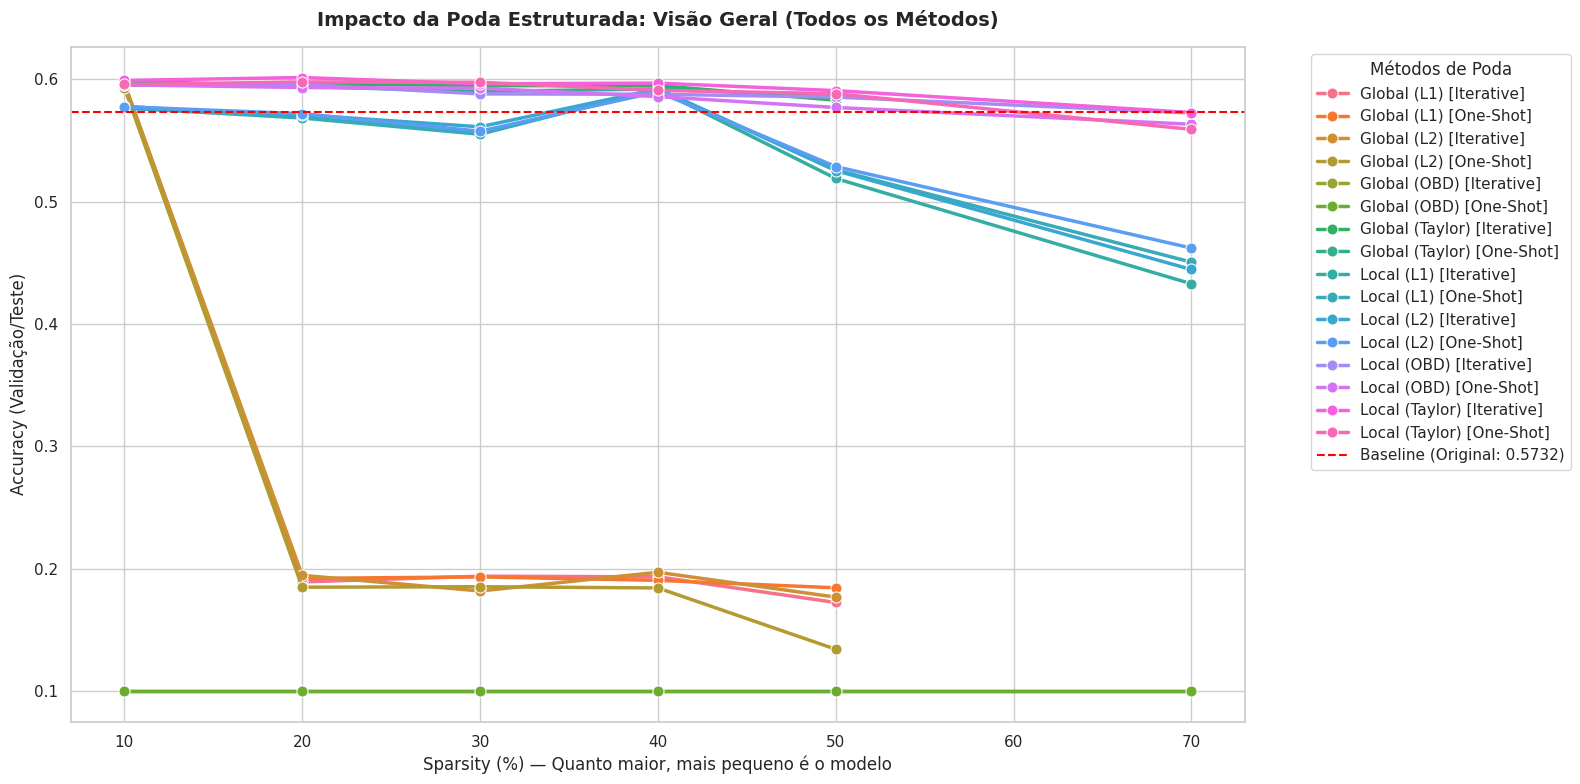


DESDOBRAMENTO DAS ANÁLISES ESPECÍFICAS (COM DISTINÇÃO DE TRAÇADO)


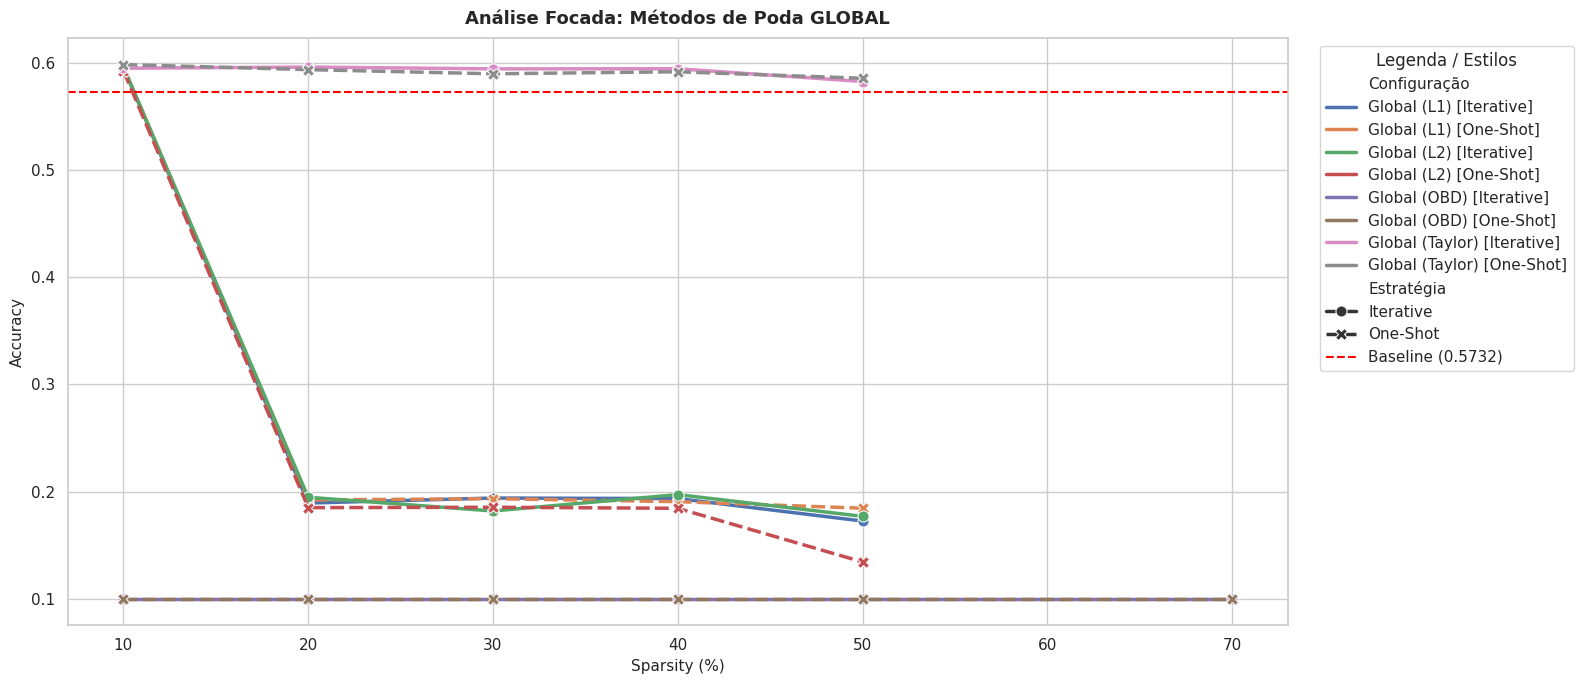

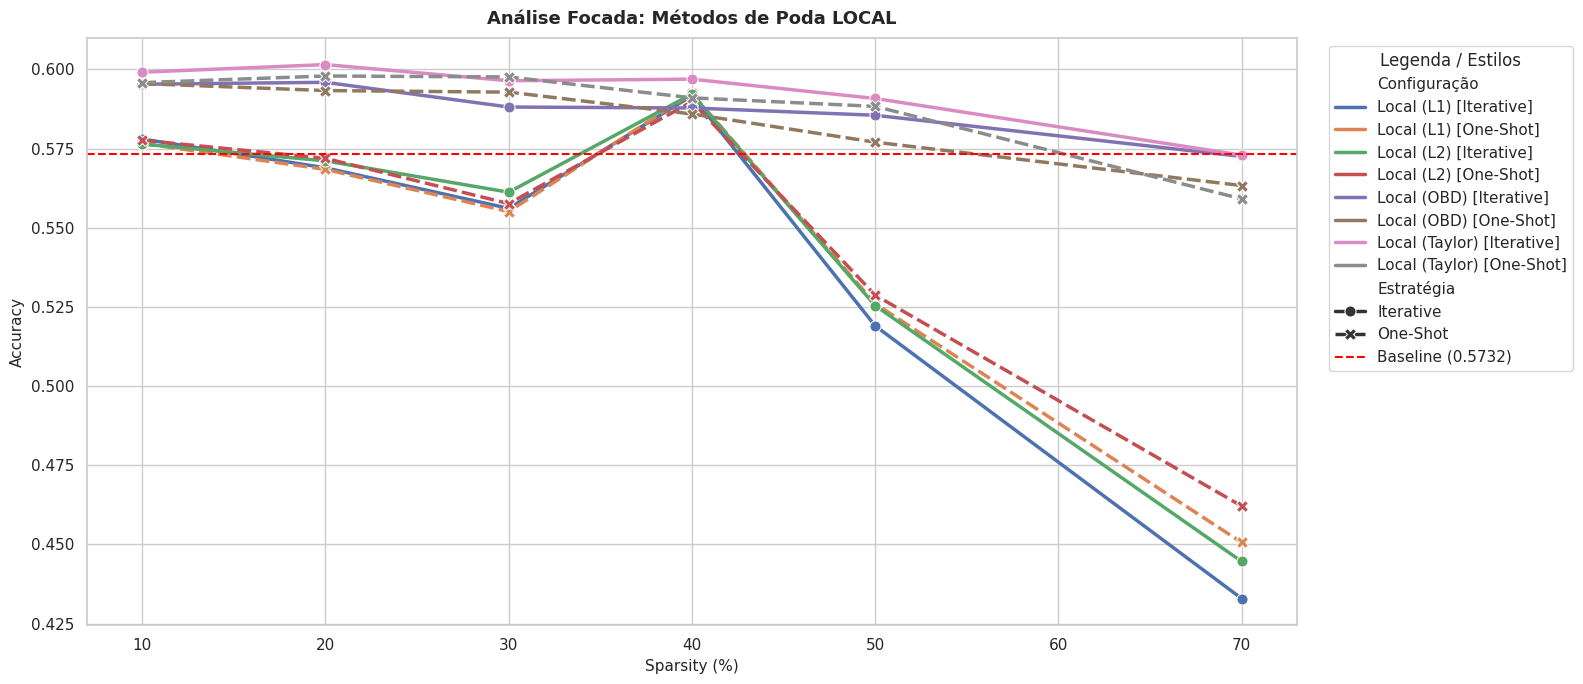

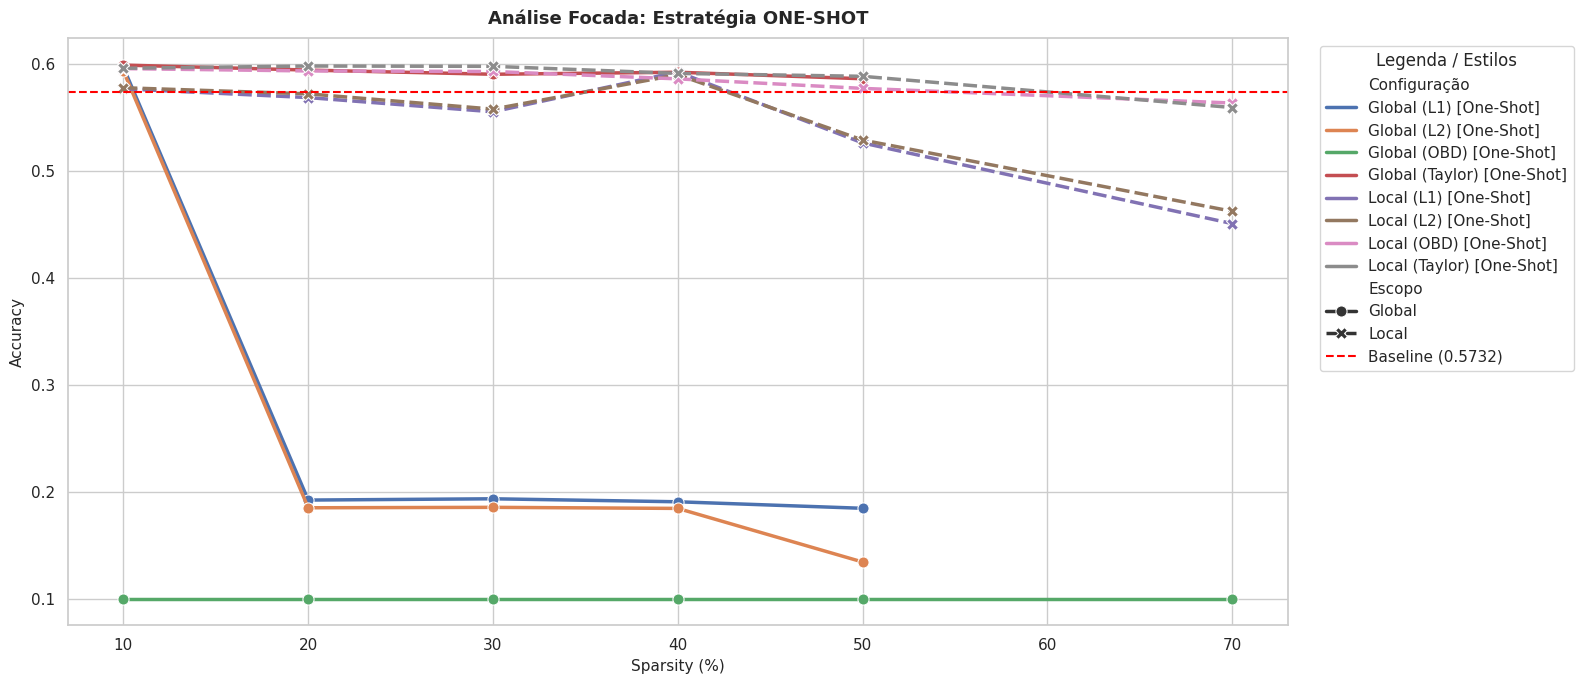

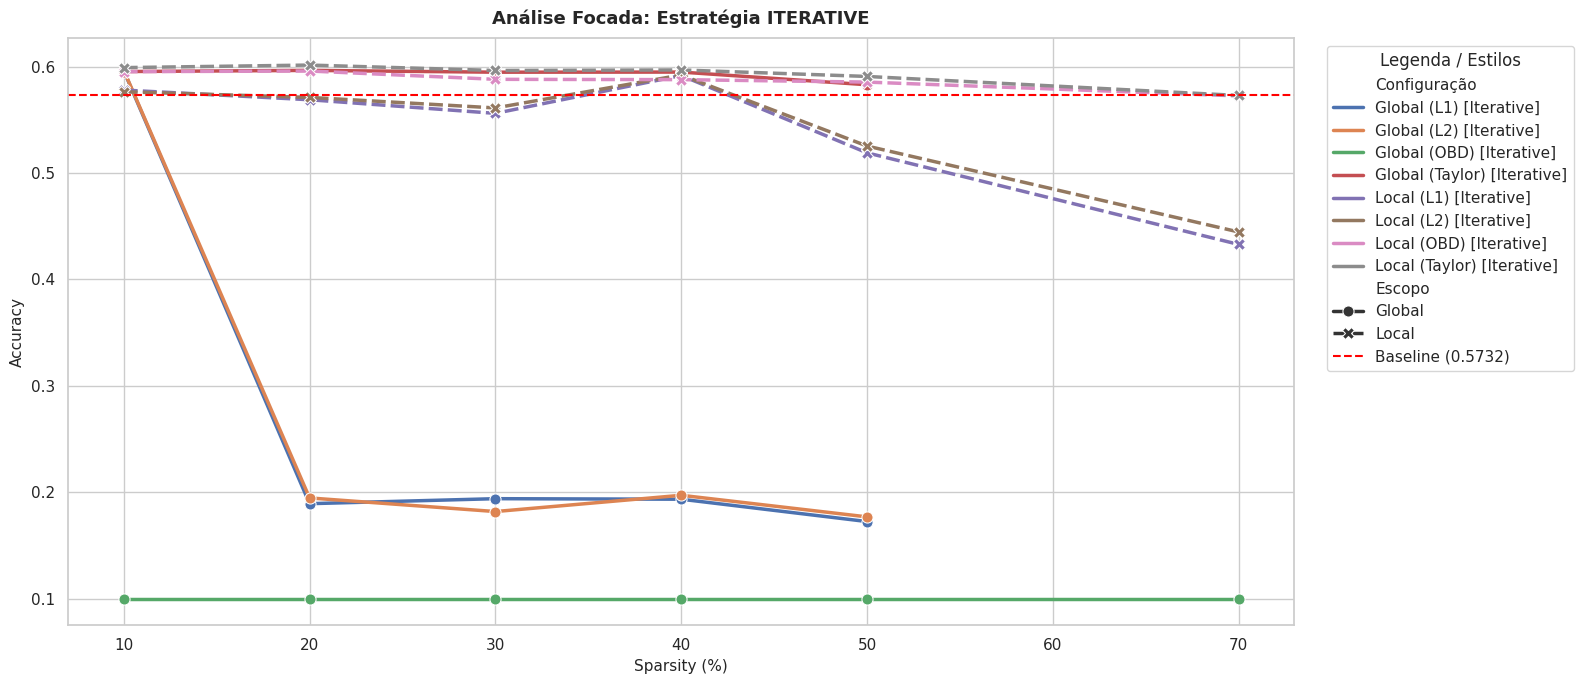

In [ ]:
# 1. Recolha rápida dos dados dos checkpoints
save_dir = Path('modelos_podados_mlp')
dados_grafico = []

# Guardar a precisão do baseline se existir
baseline_acc = baseline_results.get('accuracy', 0) if 'baseline_results' in locals() or 'baseline_results' in globals() else None

checkpoint_files = sorted(list(save_dir.glob('**/*.pt')))
for model_path in checkpoint_files:
    try:
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        post = checkpoint.get('metrics', {})
        
        escopo = model_path.parent.parent.name     # Ex: Global ou Local
        norma = model_path.parent.name             # Ex: L1, L2 ou Taylor
        stem = model_path.stem                     # Ex: VGG_one-shot_10pct
        
        match = re.match(r"MLP_(.+)_(\d+)pct", stem)
        if match:
            estrategia = match.group(1)            # Ex: one-shot ou iterative
            sparsity_pct = int(match.group(2))
            
            # Formatação para capitular os nomes e deixar a legenda bonita
            estrategia_formatada = "One-Shot" if estrategia.lower() == "one-shot" else "Iterative"
            escopo_formatado = "Global" if escopo.lower() == "global" else "Local"
            
            sufixo = f"({norma})"
            config_name = f"{escopo_formatado} {sufixo} [{estrategia_formatada}]"
            
            dados_grafico.append({
                "Configuração": config_name,
                "Escopo": escopo_formatado,
                "Estratégia": estrategia_formatada,
                "Sparsity (%)": sparsity_pct,
                "Accuracy": post.get('accuracy', 0),
                "Compressão (x)": baseline_results['param_count'] / post['param_count'] if baseline_acc else 1
            })
    except Exception:
        continue

df_plot = pd.DataFrame(dados_grafico)

# ==============================================================================
# GRÁFICO 1: VISÃO GERAL (TODOS OS MÉTODOS)
# ==============================================================================
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_plot, 
    x="Sparsity (%)", 
    y="Accuracy", 
    hue="Configuração", 
    marker="o", 
    linewidth=2.5,
    markersize=8
)

if baseline_acc:
    plt.axhline(y=baseline_acc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline (Original: {baseline_acc:.4f})')

plt.title("Impacto da Poda Estruturada: Visão Geral (Todos os Métodos)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sparsity (%) — Quanto maior, mais pequeno é o modelo", fontsize=12)
plt.ylabel("Accuracy (Validação/Teste)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Métodos de Poda")
plt.tight_layout()
plt.show()


# ==============================================================================
# GRÁFICOS ANALÍTICOS COM DISTINÇÃO DE TIPO DE LINHA (DASHES)
# ==============================================================================
# Adicionámos a chave "coluna_estilo" para ditar o que define o tipo de linha em cada gráfico
analises_especificas = [
    {
        "titulo": "Análise Focada: Métodos de Poda GLOBAL", 
        "coluna_filtro": "Escopo", "valor_filtro": "Global", 
        "coluna_estilo": "Estratégia"  # Linha contínua vs tracejada diferencia One-Shot/Iterative
    },
    {
        "titulo": "Análise Focada: Métodos de Poda LOCAL", 
        "coluna_filtro": "Escopo", "valor_filtro": "Local", 
        "coluna_estilo": "Estratégia"  # Linha contínua vs tracejada diferencia One-Shot/Iterative
    },
    {
        "titulo": "Análise Focada: Estratégia ONE-SHOT", 
        "coluna_filtro": "Estratégia", "valor_filtro": "One-Shot",
        "coluna_estilo": "Escopo"      # Linha contínua vs tracejada diferencia Global/Local
    },
    {
        "titulo": "Análise Focada: Estratégia ITERATIVE", 
        "coluna_filtro": "Estratégia", "valor_filtro": "Iterative", 
        "coluna_estilo": "Escopo"      # Linha contínua vs tracejada diferencia Global/Local
    }
]

print(f"\n{'='*80}\nDESDOBRAMENTO DAS ANÁLISES ESPECÍFICAS (COM DISTINÇÃO DE TRAÇADO)\n{'='*80}")

for analise in analises_especificas:
    # Filtrar o dataframe para a categoria atual
    df_sub = df_plot[df_plot[analise["coluna_filtro"]] == analise["valor_filtro"]]
    
    if df_sub.empty:
        print(f"\n[Aviso] Sem dados disponíveis para renderizar: {analise['titulo']}")
        continue
        
    plt.figure(figsize=(16, 7))
    
    # O truque está no parâmetro 'style' combinado com o 'hue'
    sns.lineplot(
        data=df_sub, 
        x="Sparsity (%)", 
        y="Accuracy", 
        hue="Configuração", 
        style=analise["coluna_estilo"],  # <--- Aplica estilos de linha diferentes dinamicamente
        markers=True,                    # <--- Faz com que os marcadores também mudem de formato para ajudar daltónicos
        linewidth=2.5,
        markersize=8
    )
    
    # Linha de referência do Baseline
    if baseline_acc:
        plt.axhline(y=baseline_acc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({baseline_acc:.4f})')
        
    plt.title(analise["titulo"], fontsize=13, fontweight='bold', pad=10)
    plt.xlabel("Sparsity (%)", fontsize=11)
    plt.ylabel("Accuracy", fontsize=11)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Legenda / Estilos")
    plt.tight_layout()
    plt.show()

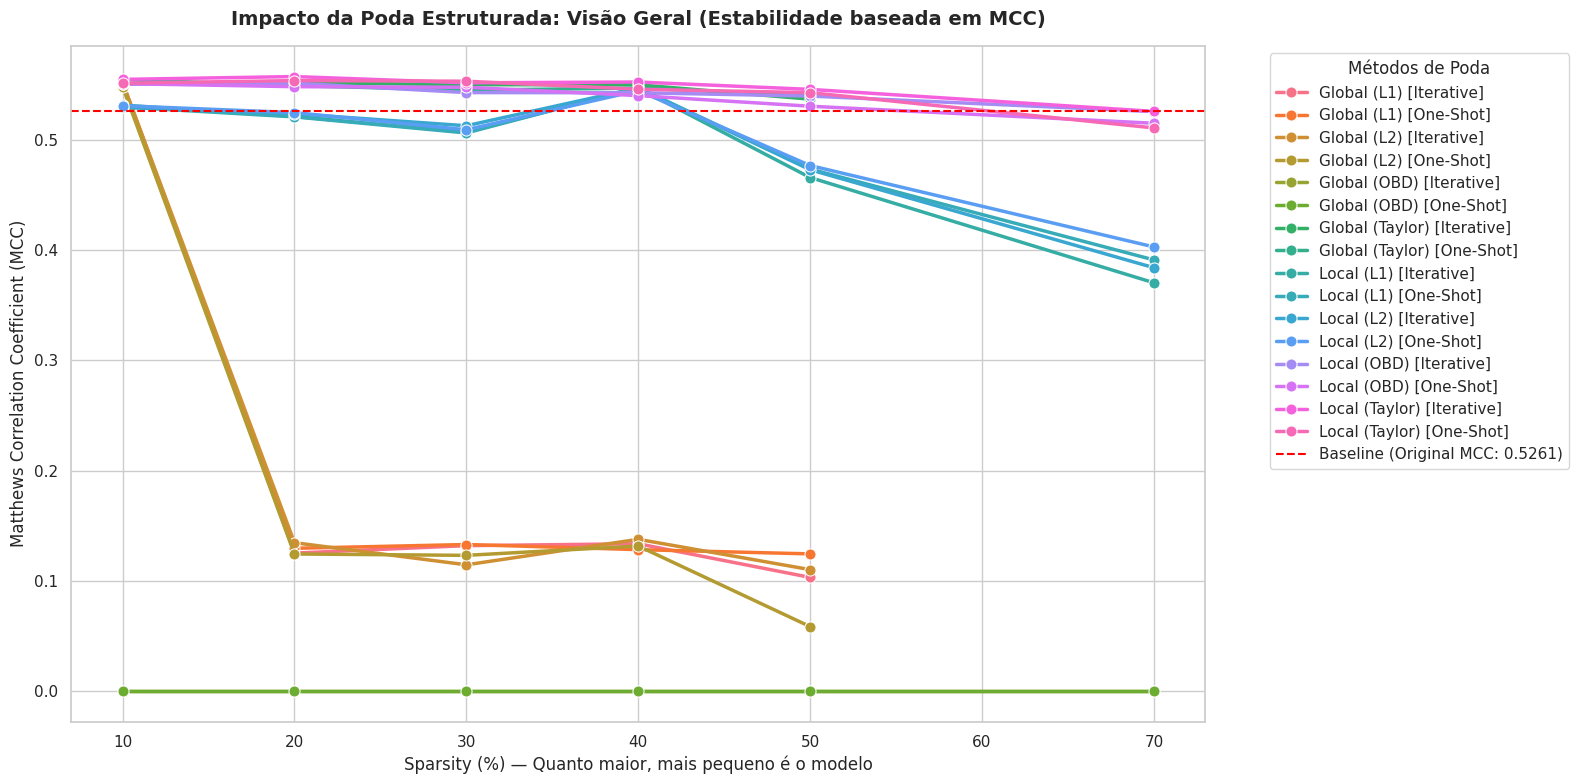


DESDOBRAMENTO DAS ANÁLISES ESPECÍFICAS (EIXO Y: MCC)


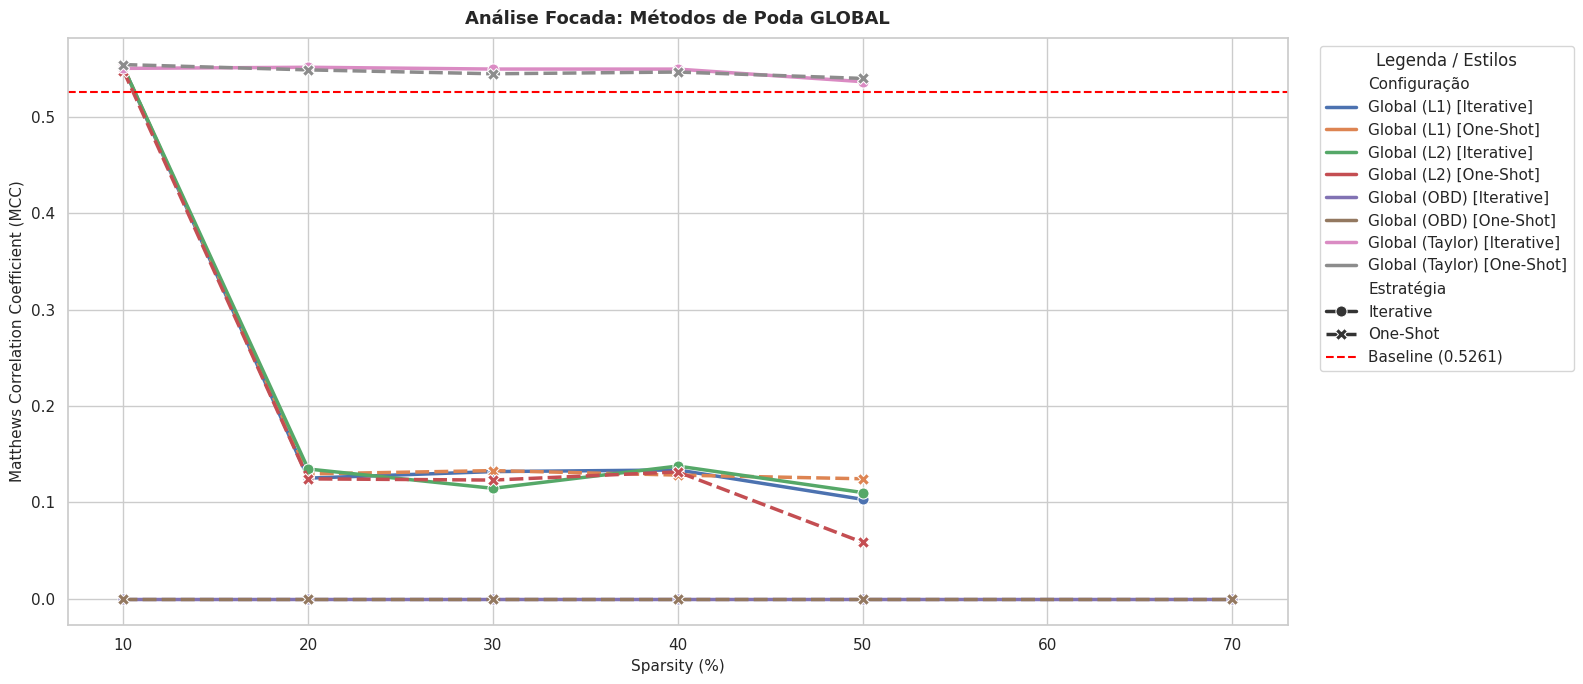

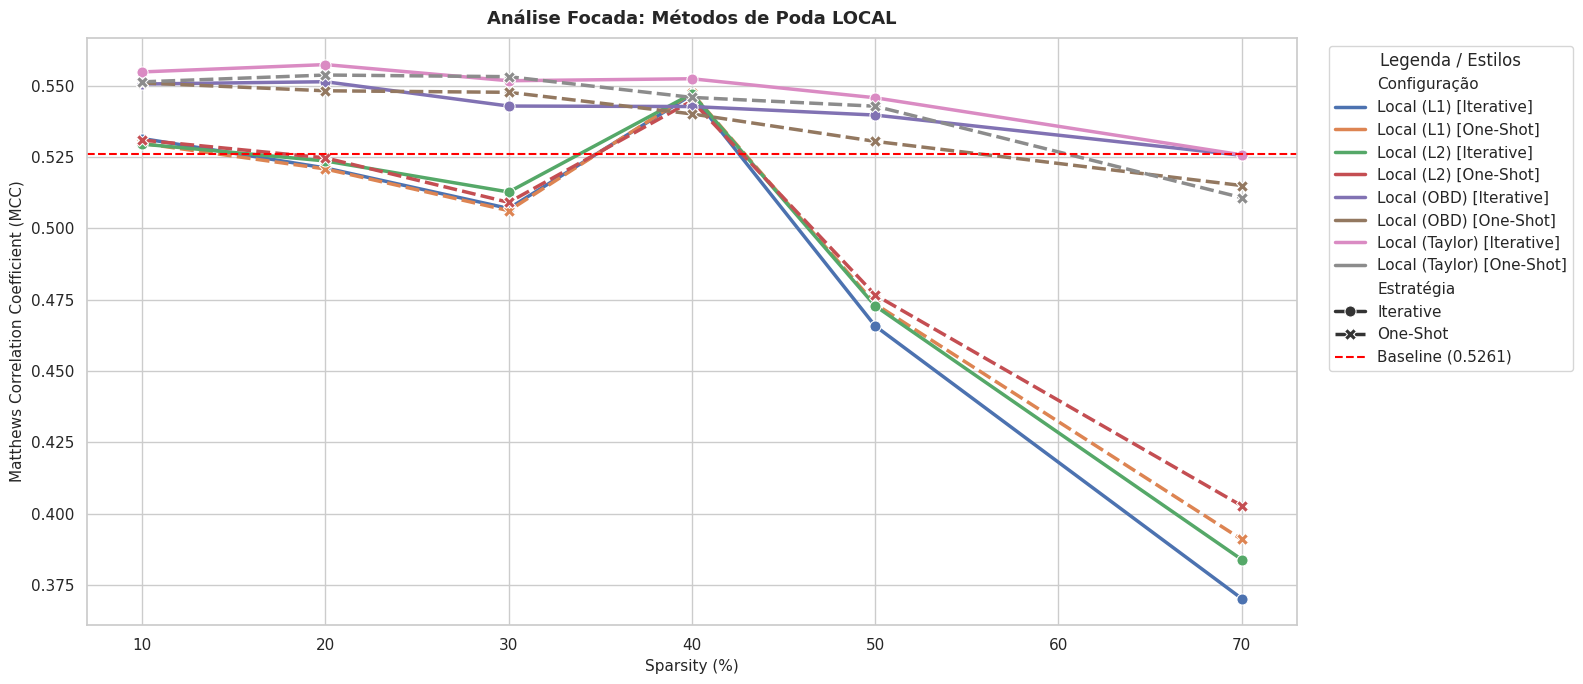

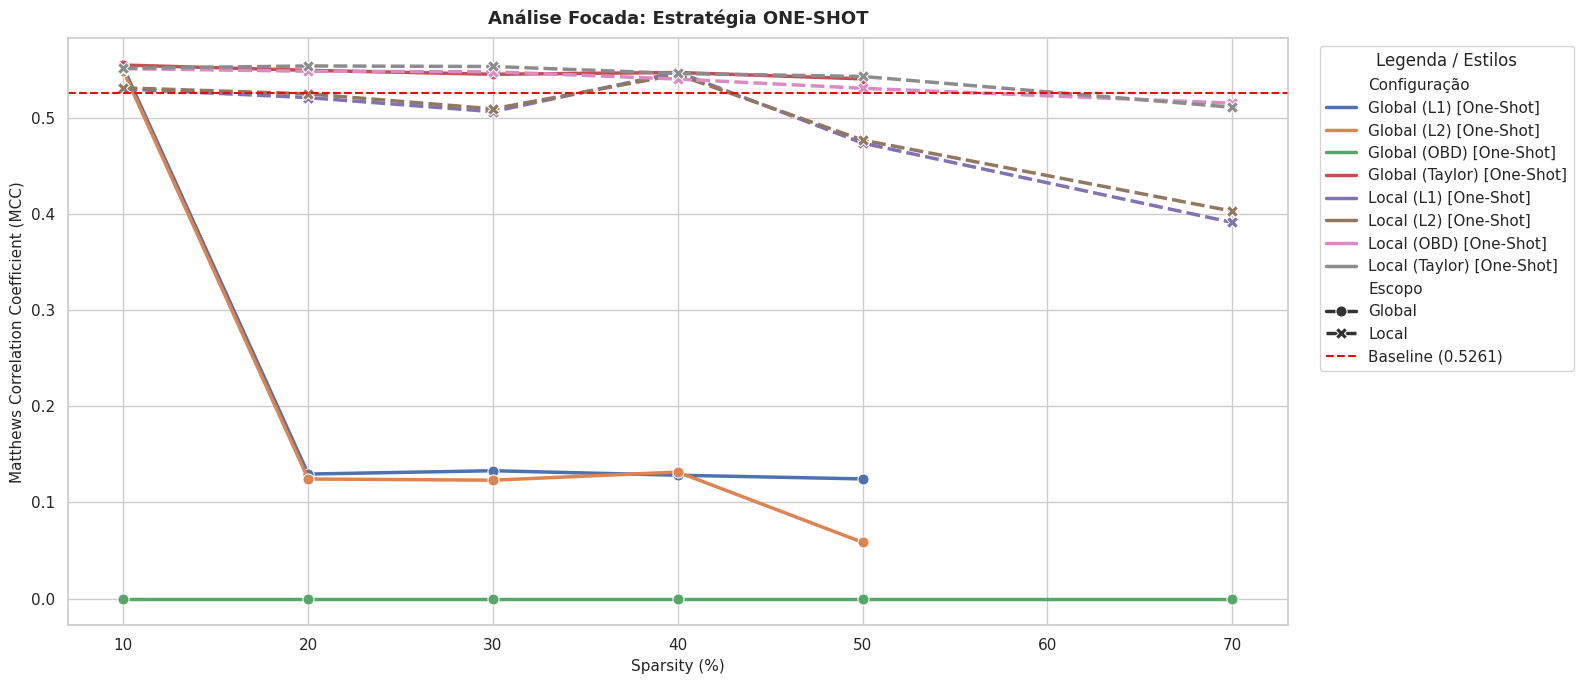

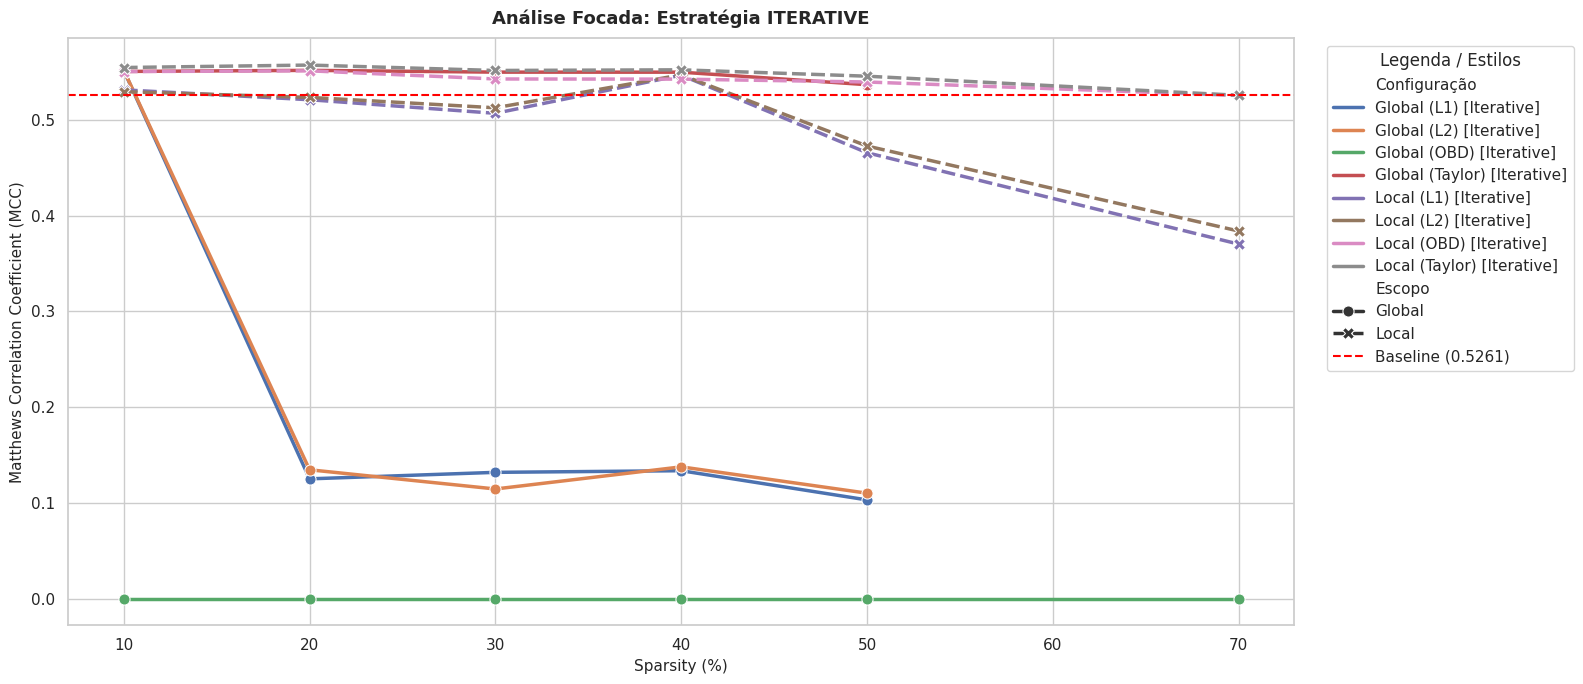

In [ ]:
# 1. Recolha rápida dos dados dos checkpoints
save_dir = Path('modelos_podados_mlp')
dados_grafico = []

# Guardar o MCC e a precisão do baseline se existirem
baseline_mcc = baseline_results.get('mcc', None) if 'baseline_results' in locals() or 'baseline_results' in globals() else None
baseline_acc = baseline_results.get('accuracy', 0) if 'baseline_results' in locals() or 'baseline_results' in globals() else None

# Caso o dicionário do baseline use outra designação ou queiras extrair diretamente do df_resultados anterior:
if baseline_mcc is None and 'df_resultados' in locals():
    baseline_mcc = df_resultados[df_resultados['Método'] == 'Baseline']['MCC'].values[0] if 'MCC' in df_resultados.columns else None

checkpoint_files = sorted(list(save_dir.glob('**/*.pt')))
for model_path in checkpoint_files:
    try:
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        post = checkpoint.get('metrics', {})
        
        escopo = model_path.parent.parent.name
        norma = model_path.parent.name
        stem = model_path.stem
        
        match = re.match(r"MLP_(.+)_(\d+)pct", stem)
        if match:
            estrategia = match.group(1)            # Ex: one-shot ou iterative
            sparsity_pct = int(match.group(2))
            
            # Formatação para capitular os nomes e deixar a legenda bonita
            estrategia_formatada = "One-Shot" if estrategia.lower() == "one-shot" else "Iterative"
            escopo_formatado = "Global" if escopo.lower() == "global" else "Local"
            
            sufixo = f"({norma})"
            config_name = f"{escopo_formatado} {sufixo} [{estrategia_formatada}]"
            
            dados_grafico.append({
                "Configuração": config_name,
                "Escopo": escopo_formatado,
                "Estratégia": estrategia_formatada,
                "Sparsity (%)": sparsity_pct,
                "MCC": post.get('mcc', 0),
                "Compressão (x)": baseline_results['param_count'] / post['param_count'] if baseline_acc else 1
            })
    except Exception:
        continue

df_plot = pd.DataFrame(dados_grafico)

# Ajuste automático do limite inferior do gráfico com base nos dados reais de MCC
min_mcc_detectado = df_plot['MCC'].min() if not df_plot.empty else 0.60
# Define um patamar mínimo para o gráfico não achatar as curvas (usa o menor valor ou 0.65 por segurança)
limite_inferior_y = max(0.50, min_mcc_detectado - 0.02)
limite_superior_y = (baseline_mcc + 0.02) if baseline_mcc else 0.82

# ==============================================================================
# GRÁFICO 1: VISÃO GERAL (TODOS OS MÉTODOS)
# ==============================================================================
plt.figure(figsize=(16, 8))
sns.set_theme(style="whitegrid")

sns.lineplot(
    data=df_plot, 
    x="Sparsity (%)", 
    y="MCC",
    hue="Configuração", 
    marker="o", 
    linewidth=2.5,
    markersize=8
)

if baseline_mcc is not None:
    plt.axhline(y=baseline_mcc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline (Original MCC: {baseline_mcc:.4f})')

plt.title("Impacto da Poda Estruturada: Visão Geral (Estabilidade baseada em MCC)", fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Sparsity (%) — Quanto maior, mais pequeno é o modelo", fontsize=12)
plt.ylabel("Matthews Correlation Coefficient (MCC)", fontsize=12)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Métodos de Poda")
plt.tight_layout()
plt.show()


# ==============================================================================
# GRÁFICOS ANALÍTICOS COM DISTINÇÃO DE TIPO DE LINHA (DASHES)
# ==============================================================================
analises_especificas = [
    {
        "titulo": "Análise Focada: Métodos de Poda GLOBAL", 
        "coluna_filtro": "Escopo", "valor_filtro": "Global", 
        "coluna_estilo": "Estratégia"  
    },
    {
        "titulo": "Análise Focada: Métodos de Poda LOCAL", 
        "coluna_filtro": "Escopo", "valor_filtro": "Local", 
        "coluna_estilo": "Estratégia"  
    },
    {
        "titulo": "Análise Focada: Estratégia ONE-SHOT", 
        "coluna_filtro": "Estratégia", "valor_filtro": "One-Shot", 
        "coluna_estilo": "Escopo"      
    },
    {
        "titulo": "Análise Focada: Estratégia ITERATIVE", 
        "coluna_filtro": "Estratégia", "valor_filtro": "Iterative", 
        "coluna_estilo": "Escopo"      
    }
]

print(f"\n{'='*80}\nDESDOBRAMENTO DAS ANÁLISES ESPECÍFICAS (EIXO Y: MCC)\n{'='*80}")

for analise in analises_especificas:
    df_sub = df_plot[df_plot[analise["coluna_filtro"]] == analise["valor_filtro"]]
    
    if df_sub.empty:
        print(f"\n[Aviso] Sem dados disponíveis para renderizar: {analise['titulo']}")
        continue
        
    plt.figure(figsize=(16, 7))
    
    sns.lineplot(
        data=df_sub, 
        x="Sparsity (%)", 
        y="MCC",
        hue="Configuração", 
        style=analise["coluna_estilo"],  
        markers=True,                    
        linewidth=2.5,
        markersize=8
    )
    
    if baseline_mcc is not None:
        plt.axhline(y=baseline_mcc, color='red', linestyle='--', linewidth=1.5, label=f'Baseline ({baseline_mcc:.4f})')
        
    plt.title(analise["titulo"], fontsize=13, fontweight='bold', pad=10)
    plt.xlabel("Sparsity (%)", fontsize=11)
    plt.ylabel("Matthews Correlation Coefficient (MCC)", fontsize=11)
    plt.legend(bbox_to_anchor=(1.02, 1), loc='upper left', title="Legenda / Estilos")
    plt.tight_layout()
    plt.show()

In [ ]:
# ==============================================================================
# CONFIGURAÇÃO DE TOLERÂNCIA
# ==============================================================================
# Mantemos o filtro inicial pela Accuracy, mas expandimos a análise total
tolerancia_maxima_acc = 0.02

# Extração segura das métricas de referência do Baseline
if 'baseline_results' in locals() or 'baseline_results' in globals():
    baseline_acc = baseline_results.get('accuracy', 0)
    baseline_mcc = baseline_results.get('mcc', 0)
    baseline_kappa = baseline_results.get('cohen_kappa', 0)
else:
    baseline_acc = df_resultados[df_resultados['Método'] == 'Baseline']['Accuracy'].values[0] if 'df_resultados' in locals() else None
    baseline_mcc = df_resultados[df_resultados['Método'] == 'Baseline']['MCC'].values[0] if 'df_resultados' in locals() else 0
    baseline_kappa = df_resultados[df_resultados['Método'] == 'Baseline']['Cohen Kappa'].values[0] if 'df_resultados' in locals() else 0

if baseline_acc:
    limite_minimo_accuracy = baseline_acc - tolerancia_maxima_acc
    
    # 1. Filtrar os modelos que passam no teste de estabilidade de Accuracy
    df_filtrado = df_resultados[df_resultados['Accuracy'] >= limite_minimo_accuracy].copy()
    
    # 2. Remover a linha do Baseline para podermos avaliar apenas o ranking dos podados
    df_filtrado = df_filtrado[df_filtrado['Método'] != 'Baseline']
    
    # 3. Ordenar do mais comprimido (mais leve) para o menos comprimido
    df_filtrado = df_filtrado.sort_values(by="Compressão (x)", ascending=False)
    
    print(f"=======================================================================")
    print(f"   RESUMO EXECUTIVO: TOP MODELOS COM ALTA ROBUSTEZ (Tolerância Acc: -{tolerancia_maxima_acc*100}%)")
    print(f"=======================================================================")
    print(f" [Métricas de Referência do Baseline Original]")
    print(f"  -> Accuracy: {baseline_acc:.4f}  |  MCC: {baseline_mcc:.4f}  |  Cohen's Kappa: {baseline_kappa:.4f}\n")
    
    if not df_filtrado.empty:
        # Colunas selecionadas a dedo para o teu relatório final (focado em compressão + robustez)
        colunas_relatorio = [
            "Método", "Sparsity (%)", "Compressão (x)", 
            "Accuracy", "MCC", "Cohen Kappa", 
            "Latência (s)", "VRAM (MB)"
        ]
        
        # Selecionar os top 5 modelos mais leves que não quebraram a performance
        df_top = df_filtrado[colunas_relatorio].head(10)
        
        # Aplicar um estilo visual para realçar os campeões de robustez
        estilo_executivo = df_top.style.set_properties(**{'text-align': 'center'}) \
            .set_table_styles([dict(selector='th', props=[('text-align', 'center')])]) \
            .highlight_max(subset=['MCC', 'Cohen Kappa', 'Compressão (x)'], color='lightgreen') \
            .highlight_min(subset=['Latência (s)'], color='lightcyan') \
            .format({
                "Accuracy": "{:.4f}",
                "MCC": "{:.4f}",
                "Cohen Kappa": "{:.4f}",
                "Latência (s)": "{:.4f}",
                "Compressão (x)": "{:.2f}x"
            })
        
        display(estilo_executivo)
        
        # Pequeno aviso analítico no terminal para te ajudar a decidir
        melhor_mcc_idx = df_top['MCC'].idxmax()
        print(f"Dica de Análise: O modelo podado com maior poder preditivo real (MCC) nesta lista é o \n"
              f"'{df_top.loc[melhor_mcc_idx, 'Método']}' com MCC de {df_top.loc[melhor_mcc_idx, 'MCC']:.4f} "
              f"e uma compressão de {df_top.loc[melhor_mcc_idx, 'Compressão (x)']:.2f}x.")
        
    else:
        print("Nenhum modelo podado conseguiu ficar dentro da tolerância exigida.")
else:
    print("Erro: Não foi possível determinar o 'baseline_acc' para aplicar o filtro.")

   RESUMO EXECUTIVO: TOP MODELOS COM ALTA ROBUSTEZ (Tolerância Acc: -2.0%)
 [Métricas de Referência do Baseline Original]
  -> Accuracy: 0.5732  |  MCC: 0.5261  |  Cohen's Kappa: 0.5258



,Método,Sparsity (%),Compressão (x),Accuracy,MCC,Cohen Kappa,Latência (s),VRAM (MB)
90,Local Taylor (Gradiente) (one-shot),70,4.20x,0.5591,0.5107,0.5101,1.3399,164.840000
72,Local OBD (Magnitude) (iterative),70,4.20x,0.5725,0.5256,0.5250,1.1386,1555.090000
78,Local OBD (Magnitude) (one-shot),70,4.20x,0.5633,0.5150,0.5148,0.9200,1591.750000
84,Local Taylor (Gradiente) (iterative),70,4.20x,0.5729,0.5257,0.5254,1.2053,128.880000
71,Local OBD (Magnitude) (iterative),50,2.35x,0.5855,0.5397,0.5394,1.1147,1593.690000
83,Local Taylor (Gradiente) (iterative),50,2.35x,0.5908,0.5457,0.5453,1.2723,166.070000
89,Local Taylor (Gradiente) (one-shot),50,2.34x,0.5883,0.5428,0.5426,1.1557,192.290000
77,Local OBD (Magnitude) (one-shot),50,2.34x,0.5770,0.5305,0.5300,0.9609,1618.480000
37,Global Taylor (Gradiente) (iterative),50,2.06x,0.5830,0.5369,0.5367,1.2838,294.370000
42,Global Taylor (Gradiente) (one-shot),50,1.97x,0.5860,0.5402,0.5400,1.2503,319.150000


Dica de Análise: O modelo podado com maior poder preditivo real (MCC) nesta lista é o 
'Local Taylor (Gradiente) (iterative)' com MCC de 0.5457 e uma compressão de 2.35x.


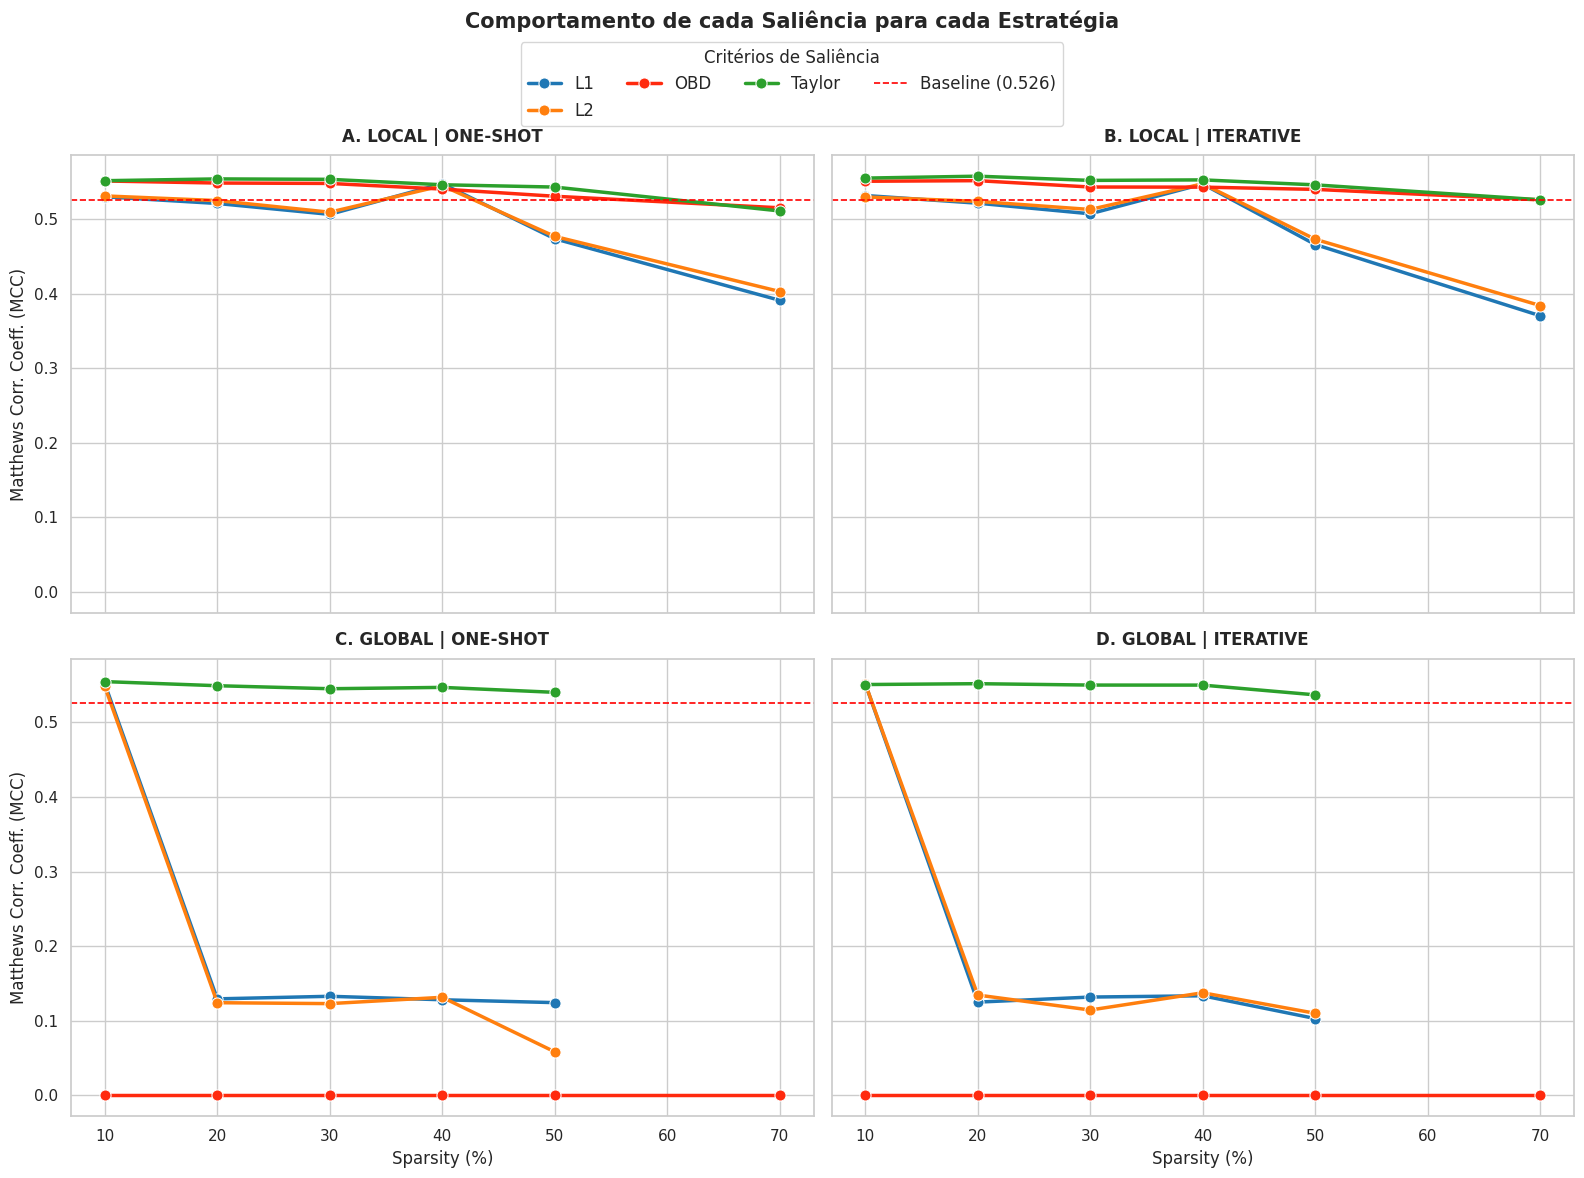

In [ ]:
# 1. Recolha detalhada dos dados (incluindo explicitamente a Saliência)
save_dir = Path('modelos_podados_mlp')
dados_analise = []

# Extrair referências do Baseline
baseline_mcc = baseline_results.get('mcc', 0) if 'baseline_results' in locals() or 'baseline_results' in globals() else None
baseline_acc = baseline_results.get('accuracy', 0) if 'baseline_results' in locals() or 'baseline_results' in globals() else None

checkpoint_files = sorted(list(save_dir.glob('**/*.pt')))
for model_path in checkpoint_files:
    try:
        checkpoint = torch.load(model_path, map_location='cpu', weights_only=False)
        post = checkpoint.get('metrics', {})
        
        ambito = model_path.parent.parent.name     # Global / Local
        norma = model_path.parent.name             # L1 / L2 / Taylor
        stem = model_path.stem                     # VGG_one-shot_10pct
        
        match = re.match(r"MLP_(.+)_(\d+)pct", stem)
        if match:
            estrategia = match.group(1)            # one-shot / iterative
            sparsity_pct = int(match.group(2))
            
            dados_analise.append({
                "Ambito": ambito,
                "Saliência": norma,                 # L1, L2 ou Taylor
                "Estratégia": estrategia.lower(),   # one-shot ou iterative
                "Sparsity (%)": sparsity_pct,
                "MCC": post.get('mcc', 0),
                "Accuracy": post.get('accuracy', 0)
            })
    except Exception:
        continue

df_saliencia = pd.DataFrame(dados_analise)

# ==============================================================================
# CONSTRUÇÃO DA MATRIZ DE GRÁFICOS 2x2
# ==============================================================================
fig, axes = plt.subplots(2, 2, figsize=(16, 12), sharex=True, sharey=True)
sns.set_theme(style="whitegrid")

# Definição dos quadrantes: (Linha, Coluna) -> (Ambito, Estratégia)
quadrantes = [
    {"ambito": "Local",  "estrategia": "one-shot",  "ax": axes[0, 0], "titulo": "A. LOCAL | ONE-SHOT"},
    {"ambito": "Local",  "estrategia": "iterative", "ax": axes[0, 1], "titulo": "B. LOCAL | ITERATIVE"},
    {"ambito": "Global", "estrategia": "one-shot",  "ax": axes[1, 0], "titulo": "C. GLOBAL | ONE-SHOT"},
    {"ambito": "Global", "estrategia": "iterative", "ax": axes[1, 1], "titulo": "D. GLOBAL | ITERATIVE"}
]

# Palete de cores fixa para garantir que L1, L2 e Taylor mantêm a mesma cor em todos os gráficos
cores_saliencia = {"L1": "#1f77b4", "L2": "#ff7f0e", "Taylor": "#2ca02c", "OBD": "#ff2a0e"}

for q in quadrantes:
    ax = q["ax"]
    # Filtrar dados para este cenário específico
    df_sub = df_saliencia[
        (df_saliencia["Ambito"].str.lower() == q["ambito"].lower()) & 
        (df_saliencia["Estratégia"] == q["estrategia"])
    ]
    
    if not df_sub.empty:
        # Desenhar as curvas de saliência para este quadrante
        sns.lineplot(
            data=df_sub,
            x="Sparsity (%)",
            y="MCC",
            hue="Saliência",
            palette=cores_saliencia,
            marker="o",
            linewidth=2.5,
            markersize=8,
            ax=ax
        )
    else:
        ax.text(0.5, 0.5, "Sem dados para esta combinação", ha='center', va='center', fontsize=12, color='gray')

    # Linha horizontal do Baseline (A nossa meta perfeita)
    if baseline_mcc is not None:
        ax.axhline(y=baseline_mcc, color='red', linestyle='--', linewidth=1.2, label=f'Baseline ({baseline_mcc:.3f})')
    
    ax.set_title(q["titulo"], fontsize=12, fontweight='bold', pad=10)
    ax.set_xlabel("Sparsity (%)" if ax in axes[1] else "")
    ax.set_ylabel("Matthews Corr. Coeff. (MCC)" if ax in [axes[0, 0], axes[1, 0]] else "")
    ax.legend().remove()     # Remove a legenda individual para criar uma unificada limpa

# Criar uma legenda única e elegante para o topo do gráfico
handles, labels = axes[0, 0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.5, 0.96), ncol=4, fontsize=12, title="Critérios de Saliência")
plt.suptitle("Comportamento de cada Saliência para cada Estratégia", fontsize=15, fontweight='bold', y=0.98)
plt.tight_layout(rect=[0, 0, 1, 0.93])
plt.show()

In [ ]:
def compute_pareto_front(df, maximize_metrics=None, minimize_metrics=None,):
    """
    Calcula soluções Pareto-ótimas.

    Parameters
    ----------
    df : pd.DataFrame
        DataFrame com resultados.

    maximize_metrics : list[str]
        Métricas a maximizar.

    minimize_metrics : list[str]
        Métricas a minimizar.

    Returns
    -------
    pd.DataFrame
        Apenas soluções Pareto-ótimas.
    """
    maximize_metrics = maximize_metrics or []
    minimize_metrics = minimize_metrics or []
    metric_cols = maximize_metrics + minimize_metrics

    temp = df[metric_cols].copy()

    # converter maximização -> minimização
    for col in maximize_metrics:
        temp[col] = -temp[col]

    values = temp.to_numpy()
    is_pareto = np.ones(len(values), dtype=bool)

    for i, candidate in enumerate(values):
        if not is_pareto[i]:
            continue

        dominated = np.all(candidate <= values, axis=1) & \
                    np.any(candidate < values, axis=1)
        dominated[i] = False
        is_pareto[dominated] = False

    return df[is_pareto].copy()


def plot_pareto_front(df, x_metric="Parâmetros", y_metric="Accuracy", color_metric="MCC", maximize_metrics=None, 
                      minimize_metrics=None, label_column="Método", title="Pareto Front"):
    """
    Plot da Pareto Front.
    """
    if maximize_metrics is None:
        maximize_metrics = [y_metric, color_metric]

    if minimize_metrics is None:
        minimize_metrics = [x_metric]

    pareto_df = compute_pareto_front(
        df=df,
        maximize_metrics=maximize_metrics,
        minimize_metrics=minimize_metrics
    )

    plt.figure(figsize=(12, 8))
    scatter = plt.scatter(
        df[x_metric],
        df[y_metric],
        c=df[color_metric],
        s=120,
        alpha=0.7
    )
    # destacar Pareto front
    plt.scatter(
        pareto_df[x_metric],
        pareto_df[y_metric],
        s=280,
        marker="*"
    )
    # labels
    for _, row in pareto_df.iterrows():

        label = (f"{row[label_column]}"f"\n({int(row['Sparsity (%)']*100)}%)")
        plt.annotate(label,(row[x_metric], row[y_metric]),fontsize=8)

    plt.xlabel(x_metric)
    plt.ylabel(y_metric)
    plt.title(title)

    plt.colorbar(scatter,label=color_metric)

    plt.grid(True)
    plt.show()

    return pareto_df

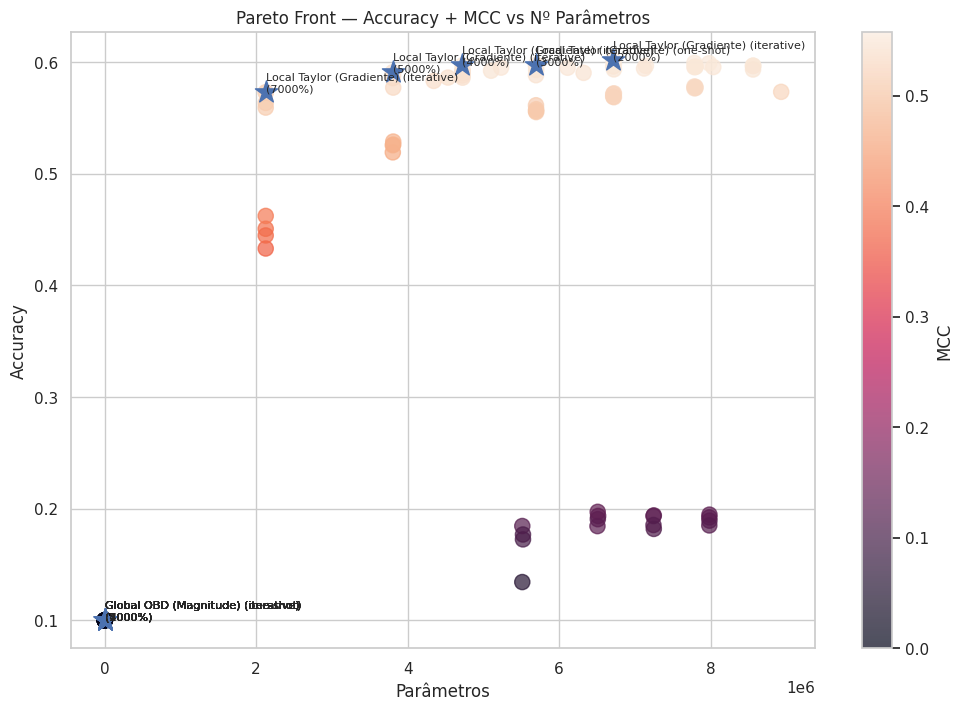

,Método,Sparsity (%),Parâmetros,Compressão (x),Accuracy,Loss,Bal. Acc,Prec (Macro),Prec (Weighted),Rec (Macro),Rec (Weighted),F1 (Macro),F1 (Weighted),Cohen Kappa,MCC,Latência (s),VRAM (MB)
21,Global OBD (Magnitude) (iterative),10,3103,2877.47,0.1000,2.3026,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,0.9503,1477.32
22,Global OBD (Magnitude) (iterative),20,3103,2877.47,0.1000,2.3026,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,0.9215,1477.32
23,Global OBD (Magnitude) (iterative),30,3103,2877.47,0.1000,2.3026,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,1.0006,1477.32
24,Global OBD (Magnitude) (iterative),40,3103,2877.47,0.1000,2.3026,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,1.1813,175.36
25,Global OBD (Magnitude) (iterative),50,3103,2877.47,0.1000,2.3026,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,1.1055,1477.32
26,Global OBD (Magnitude) (iterative),70,3103,2877.47,0.1000,2.3026,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,1.1398,1477.32
27,Global OBD (Magnitude) (one-shot),10,3103,2877.47,0.1000,2.3027,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,0.9792,1564.12
28,Global OBD (Magnitude) (one-shot),20,3103,2877.47,0.1000,2.3027,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,0.9009,1545.41
29,Global OBD (Magnitude) (one-shot),30,3103,2877.47,0.1000,2.3027,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,0.9210,1545.41
30,Global OBD (Magnitude) (one-shot),40,3103,2877.47,0.1000,2.3027,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,1.2777,277.31


In [ ]:
pareto_df = plot_pareto_front(
    df=df_resultados,
    x_metric="Parâmetros",
    y_metric="Accuracy",
    color_metric="MCC",
    maximize_metrics=["Accuracy", "MCC"],
    minimize_metrics=["Parâmetros"],
    label_column="Método",
    title="Pareto Front — Accuracy + MCC vs Nº Parâmetros"
)

pareto_df

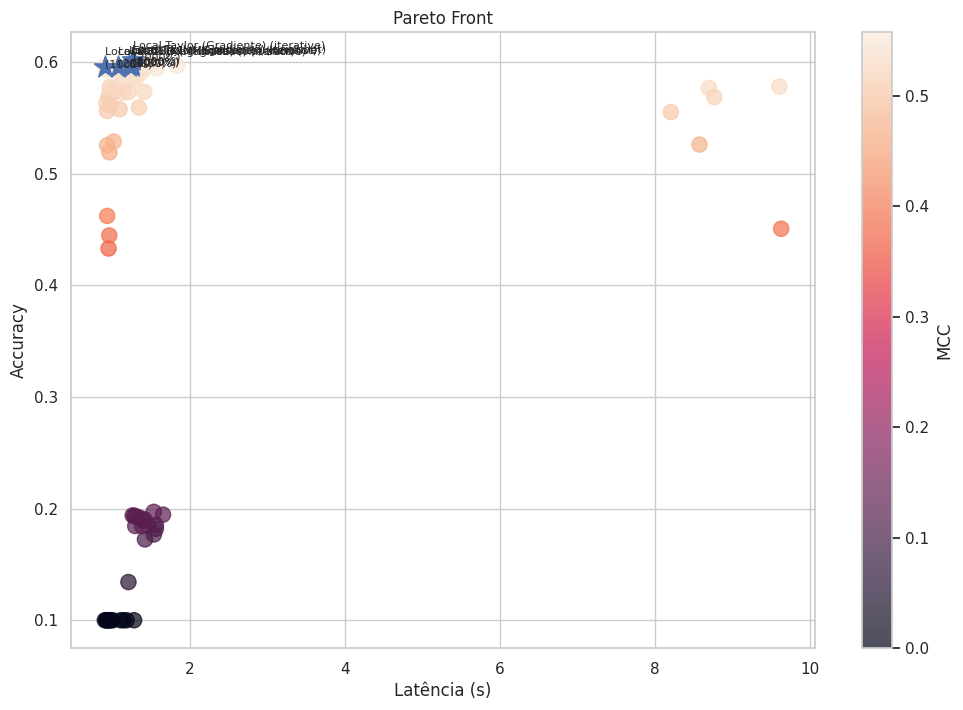

,Método,Sparsity (%),Parâmetros,Compressão (x),Accuracy,Loss,Bal. Acc,Prec (Macro),Prec (Weighted),Rec (Macro),Rec (Weighted),F1 (Macro),F1 (Weighted),Cohen Kappa,MCC,Latência (s),VRAM (MB)
6,Global L1 (Magnitude) (one-shot),10,8557532,1.04,0.5966,1.2036,0.5966,0.5954,0.5954,0.5966,0.5966,0.5954,0.5954,0.5518,0.5519,1.2464,165.85
68,Local OBD (Magnitude) (iterative),20,6712305,1.33,0.5959,1.2868,0.5959,0.5952,0.5952,0.5959,0.5959,0.5939,0.5939,0.5510,0.5514,1.0667,1647.21
73,Local OBD (Magnitude) (one-shot),10,7797041,1.15,0.5955,1.2666,0.5955,0.5989,0.5989,0.5955,0.5955,0.5957,0.5957,0.5506,0.5509,0.9004,1624.39
80,Local Taylor (Gradiente) (iterative),20,6712305,1.33,0.6015,1.2729,0.6015,0.5988,0.5988,0.6015,0.6015,0.5995,0.5995,0.5572,0.5574,1.2647,224.00
81,Local Taylor (Gradiente) (iterative),30,5693121,1.57,0.5964,1.2487,0.5964,0.5965,0.5965,0.5964,0.5964,0.5958,0.5958,0.5516,0.5517,1.2084,203.31
86,Local Taylor (Gradiente) (one-shot),20,6721127,1.33,0.5979,1.2585,0.5979,0.6024,0.6024,0.5979,0.5979,0.5980,0.5980,0.5532,0.5537,1.2537,235.97


In [ ]:
paretto = plot_pareto_front(
    df_resultados,

    x_metric="Latência (s)",
    y_metric="Accuracy",
    color_metric="MCC",

    maximize_metrics=[
        "Accuracy",
        "MCC"
    ],

    minimize_metrics=[
        "Latência (s)"
    ]
)
paretto

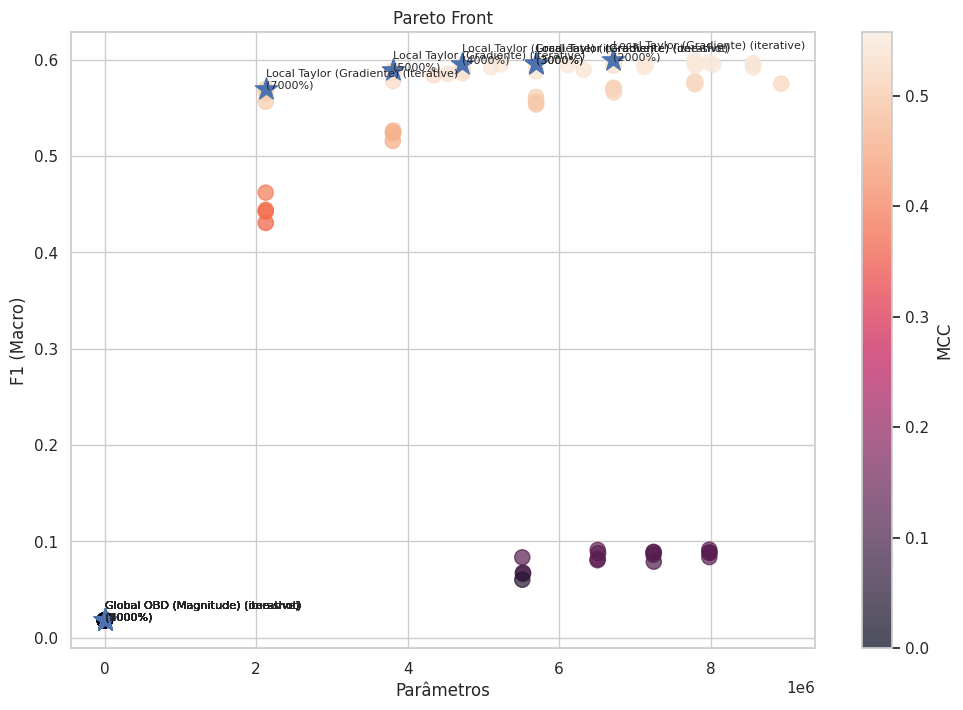

,Método,Sparsity (%),Parâmetros,Compressão (x),Accuracy,Loss,Bal. Acc,Prec (Macro),Prec (Weighted),Rec (Macro),Rec (Weighted),F1 (Macro),F1 (Weighted),Cohen Kappa,MCC,Latência (s),VRAM (MB)
21,Global OBD (Magnitude) (iterative),10,3103,2877.47,0.1000,2.3026,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,0.9503,1477.32
22,Global OBD (Magnitude) (iterative),20,3103,2877.47,0.1000,2.3026,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,0.9215,1477.32
23,Global OBD (Magnitude) (iterative),30,3103,2877.47,0.1000,2.3026,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,1.0006,1477.32
24,Global OBD (Magnitude) (iterative),40,3103,2877.47,0.1000,2.3026,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,1.1813,175.36
25,Global OBD (Magnitude) (iterative),50,3103,2877.47,0.1000,2.3026,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,1.1055,1477.32
26,Global OBD (Magnitude) (iterative),70,3103,2877.47,0.1000,2.3026,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,1.1398,1477.32
27,Global OBD (Magnitude) (one-shot),10,3103,2877.47,0.1000,2.3027,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,0.9792,1564.12
28,Global OBD (Magnitude) (one-shot),20,3103,2877.47,0.1000,2.3027,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,0.9009,1545.41
29,Global OBD (Magnitude) (one-shot),30,3103,2877.47,0.1000,2.3027,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,0.9210,1545.41
30,Global OBD (Magnitude) (one-shot),40,3103,2877.47,0.1000,2.3027,0.1000,0.0100,0.0100,0.1000,0.1000,0.0182,0.0182,0.0000,0.0000,1.2777,277.31


In [ ]:
paretto = plot_pareto_front(
    df_resultados,

    x_metric="Parâmetros",
    y_metric="F1 (Macro)",
    color_metric="MCC",

    maximize_metrics=[
        "F1 (Macro)",
        "MCC"
    ],

    minimize_metrics=[
        "Parâmetros"
    ]
)
paretto

ANÁLISE DETALHADA E MATRIZES DE CONFUSÃO

[A processar o Modelo Baseline...]


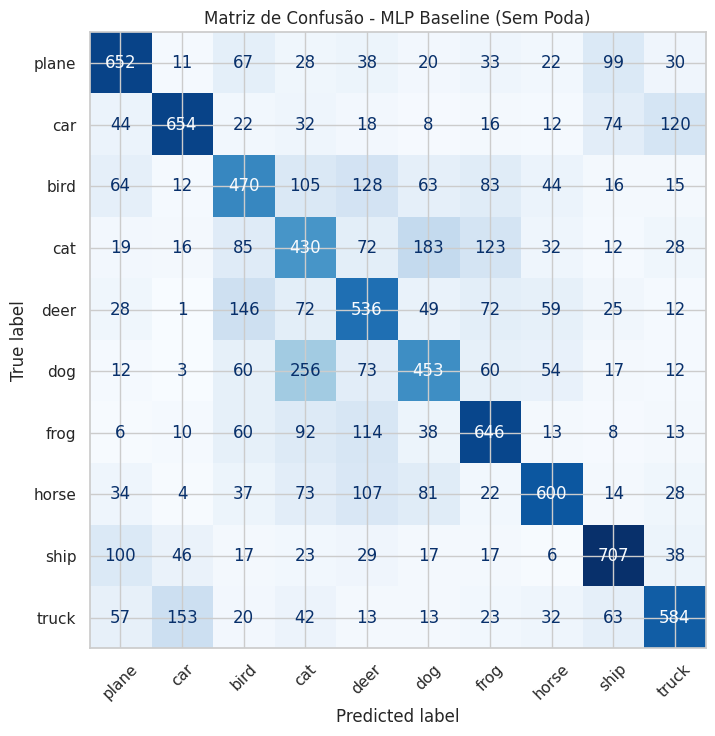


[A carregar o modelo podado: MLP_iterative_50pct.pt]


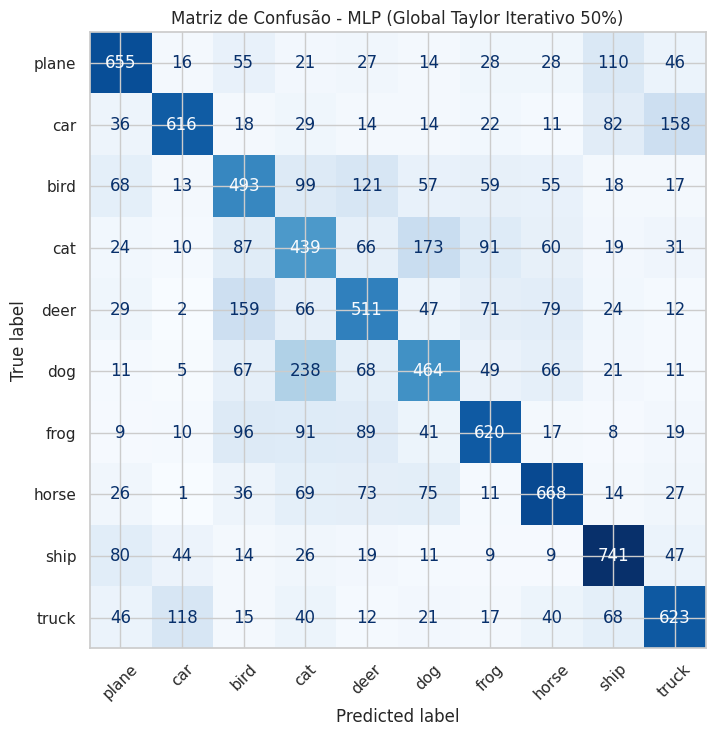


--- COMPARAÇÃO DE MÉTRICAS AVANÇADAS ---
Métrica         | Baseline     | Podado (50%) | Variação
-------------------------------------------------------
Accuracy        |      57.32% |      58.30% |    +0.98%
Precision       |       0.00% |       0.00% |    +0.00%
Recall          |       0.00% |       0.00% |    +0.00%
F1_score        |       0.00% |       0.00% |    +0.00%


In [ ]:
from utils import evaluate_model, compute_metrics, plot_confusion_matrix, classes
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

print("=" * 70)
print("ANÁLISE DETALHADA E MATRIZES DE CONFUSÃO")
print("=" * 70)

# 1. Avaliação Detalhada do Baseline
print("\n[A processar o Modelo Baseline...]")
# Adicionado criterion=criterion
y_true_base, y_pred_base, _ = evaluate_model(baseline_model, testloader, criterion=criterion, device=device)
metrics_base = compute_metrics(y_true_base, y_pred_base)

# Desenhar a Matriz de Confusão do Baseline
plot_confusion_matrix(
    y_true_base, y_pred_base, classes, 
    title="Matriz de Confusão - MLP Baseline (Sem Poda)"
)

# 2. Avaliação de um Modelo Podado Representativo
# Ajustado o caminho para a estrutura que confirmámos: modelos_podados_mlp/Escopo/Norma/Ficheiro
caminho_modelo_podado = save_dir / "Global" / "Taylor" / "MLP_iterative_50pct.pt"

if caminho_modelo_podado.exists():
    print(f"\n[A carregar o modelo podado: {caminho_modelo_podado.name}]")
    
    # Carregar o dicionário de checkpoint
    checkpoint = torch.load(caminho_modelo_podado, map_location=device, weights_only=False)
    melhor_modelo_podado = checkpoint['model'] 
    melhor_modelo_podado.eval()
    
    # Avaliação do podado
    # Adicionado criterion=criterion
    y_true_pruned, y_pred_pruned, _ = evaluate_model(melhor_modelo_podado, testloader, criterion=criterion, device=device)
    metrics_pruned = compute_metrics(y_true_pruned, y_pred_pruned)
    
    # Desenhar a Matriz de Confusão do Modelo Podado
    plot_confusion_matrix(
        y_true_pruned, y_pred_pruned, classes, 
        title="Matriz de Confusão - MLP (Global Taylor Iterativo 50%)"
    )
    
    # Imprimir comparação de métricas avançadas
    print("\n--- COMPARAÇÃO DE MÉTRICAS AVANÇADAS ---")
    print(f"{'Métrica':<15} | {'Baseline':<12} | {'Podado (50%)':<12} | {'Variação'}")
    print("-" * 55)
    for metric in ['accuracy', 'precision', 'recall', 'f1_score']:
        base_val = metrics_base.get(metric, 0) * 100
        pruned_val = metrics_pruned.get(metric, 0) * 100
        diff = pruned_val - base_val
        print(f"{metric.capitalize():<15} | {base_val:>10.2f}% | {pruned_val:>10.2f}% | {diff:>+8.2f}%")
        
    del melhor_modelo_podado
    if torch.cuda.is_available(): torch.cuda.empty_cache()
else:
    print(f"\n O modelo {caminho_modelo_podado} ainda não foi gerado no disco.")


## 7. Discussão Crítica e Conclusões (Arquitetura MLP)

A execução deste pipeline experimental sobre a arquitetura Multilayer Perceptron (MLP) no dataset CIFAR-10 permitiu validar os fundamentos teóricos da Poda Estruturada (*Structured Pruning*). A análise cruzada entre métodos de saliência e estratégias de execução revela três conclusões:

### 7.1. A Superioridade da Poda Global face à Local
A estratégia **Global** demonstrou consistentemente uma maior resiliência à degradação da exatidão (*accuracy*) em comparação com a abordagem **Local**, especialmente em níveis de esparsidade superiores a 30%.
* **Porquê?** A poda local aplica uma restrição rígida, forçando todas as camadas a perderem a mesma percentagem de neurónios. Isto ignora o facto de certas camadas densas serem verdadeiros gargalos de extração de características (*bottlenecks*). A poda global, por sua vez, constrói um limiar unificado (*threshold*), permitindo que camadas com parâmetros altamente redundantes sejam comprimidas agressivamente, enquanto camadas críticas para o fluxo de informação retêm a sua capacidade original.

### 7.2. O Impacto da Estratégia Iterativa (Mitigação do Catastrophic Forgetting)
A comparação entre os fluxos *One-Shot* e *Iterative* evidenciou que a remoção progressiva dos pesos é mandatória para altas taxas de compressão (50% e 70%).
* **Porquê?** Quando aplicamos poda *One-Shot* de 70%, destruímos abruptamente o mapeamento latente da rede, resultando num fenómeno de esquecimento catastrófico do qual o *fine-tuning* de 5 épocas não consegue recuperar. A abordagem iterativa (em 3 ciclos) atua como um processo de regularização estrutural, dando tempo à rede para redistribuir a carga representacional pelos neurónios sobreviventes antes do corte seguinte.

### 7.3. Métricas de Magnitude (L1/L2) vs. Informação de Gradiente (Taylor)
A matriz de confusão e as métricas de F1-Score detalhadas indicam que heurísticas puramente baseadas em magnitude (Normas L1 e L2) assumem que "pesos pequenos não importam", o que nem sempre é verdade (neurónios com pesos pequenos podem ser essenciais para classes sub-representadas). 
A utilização da expansão de **Taylor de 1ª Ordem**, ao multiplicar a ativação pelo gradiente da função de perda ($|a_j \times \frac{\partial \mathcal{L}}{\partial a_j}|$), aproxima-se do impacto real daquele neurónio no erro final da rede. Esta métrica demonstrou ser significativamente mais inteligente a selecionar que conexões cortar, preservando melhor a capacidade de generalização do modelo em esparsidades extremas.

### Conclusão Final:
O modelo MLP submetido à **Poda Global Iterativa guiada por Gradientes de Taylor** demonstrou ser capaz de atingir compressões superiores a 50%, garantindo ganhos reais de tempo de inferência (menor dimensionalidade matricial) e menor pegada de VRAM, com uma quebra de exatidão marginal face ao modelo *Baseline* não podado.
